In [1]:
# Project setup
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Imports, Data Loading and Plotting Config

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

from src.data.loaders import PointsDataset
from src.visualization.visualization_utils import create_meshgrid
from src.visualization.feature_space_plots import plot_in_rectangular_coordinates, PlotManager
from src.models.logistic_regression import train_logistic_regression
from src.models.svm import train_svm
from src.visualization.decision_boundaries import plot_decision_boundary
from src.evaluation.metrics import ModelMetrics
from src.features.transformations import cartesian_to_polar, cartesian_to_elliptic, polar_to_curvilinear_cos2theta

In [3]:
current_dir = Path.cwd()

# Load the dataset
data_path = current_dir.parent / "data" / "raw" / "points.json"
dataset = PointsDataset.from_json(data_path=data_path)

In [4]:
PLOT_CONFIG = {
    "show": True,
    "save": True,
    "out_dir": current_dir.parent / "results" / "figures"
}

plot_manager = PlotManager(PLOT_CONFIG)

---------------------

# Feature Transformations

## Feature Transformation: Polar Coordinates

Test whether radial symmetry enables separability.

In [5]:
# Transform data points into polar form
polar_dataset = dataset.transform(cartesian_to_polar)

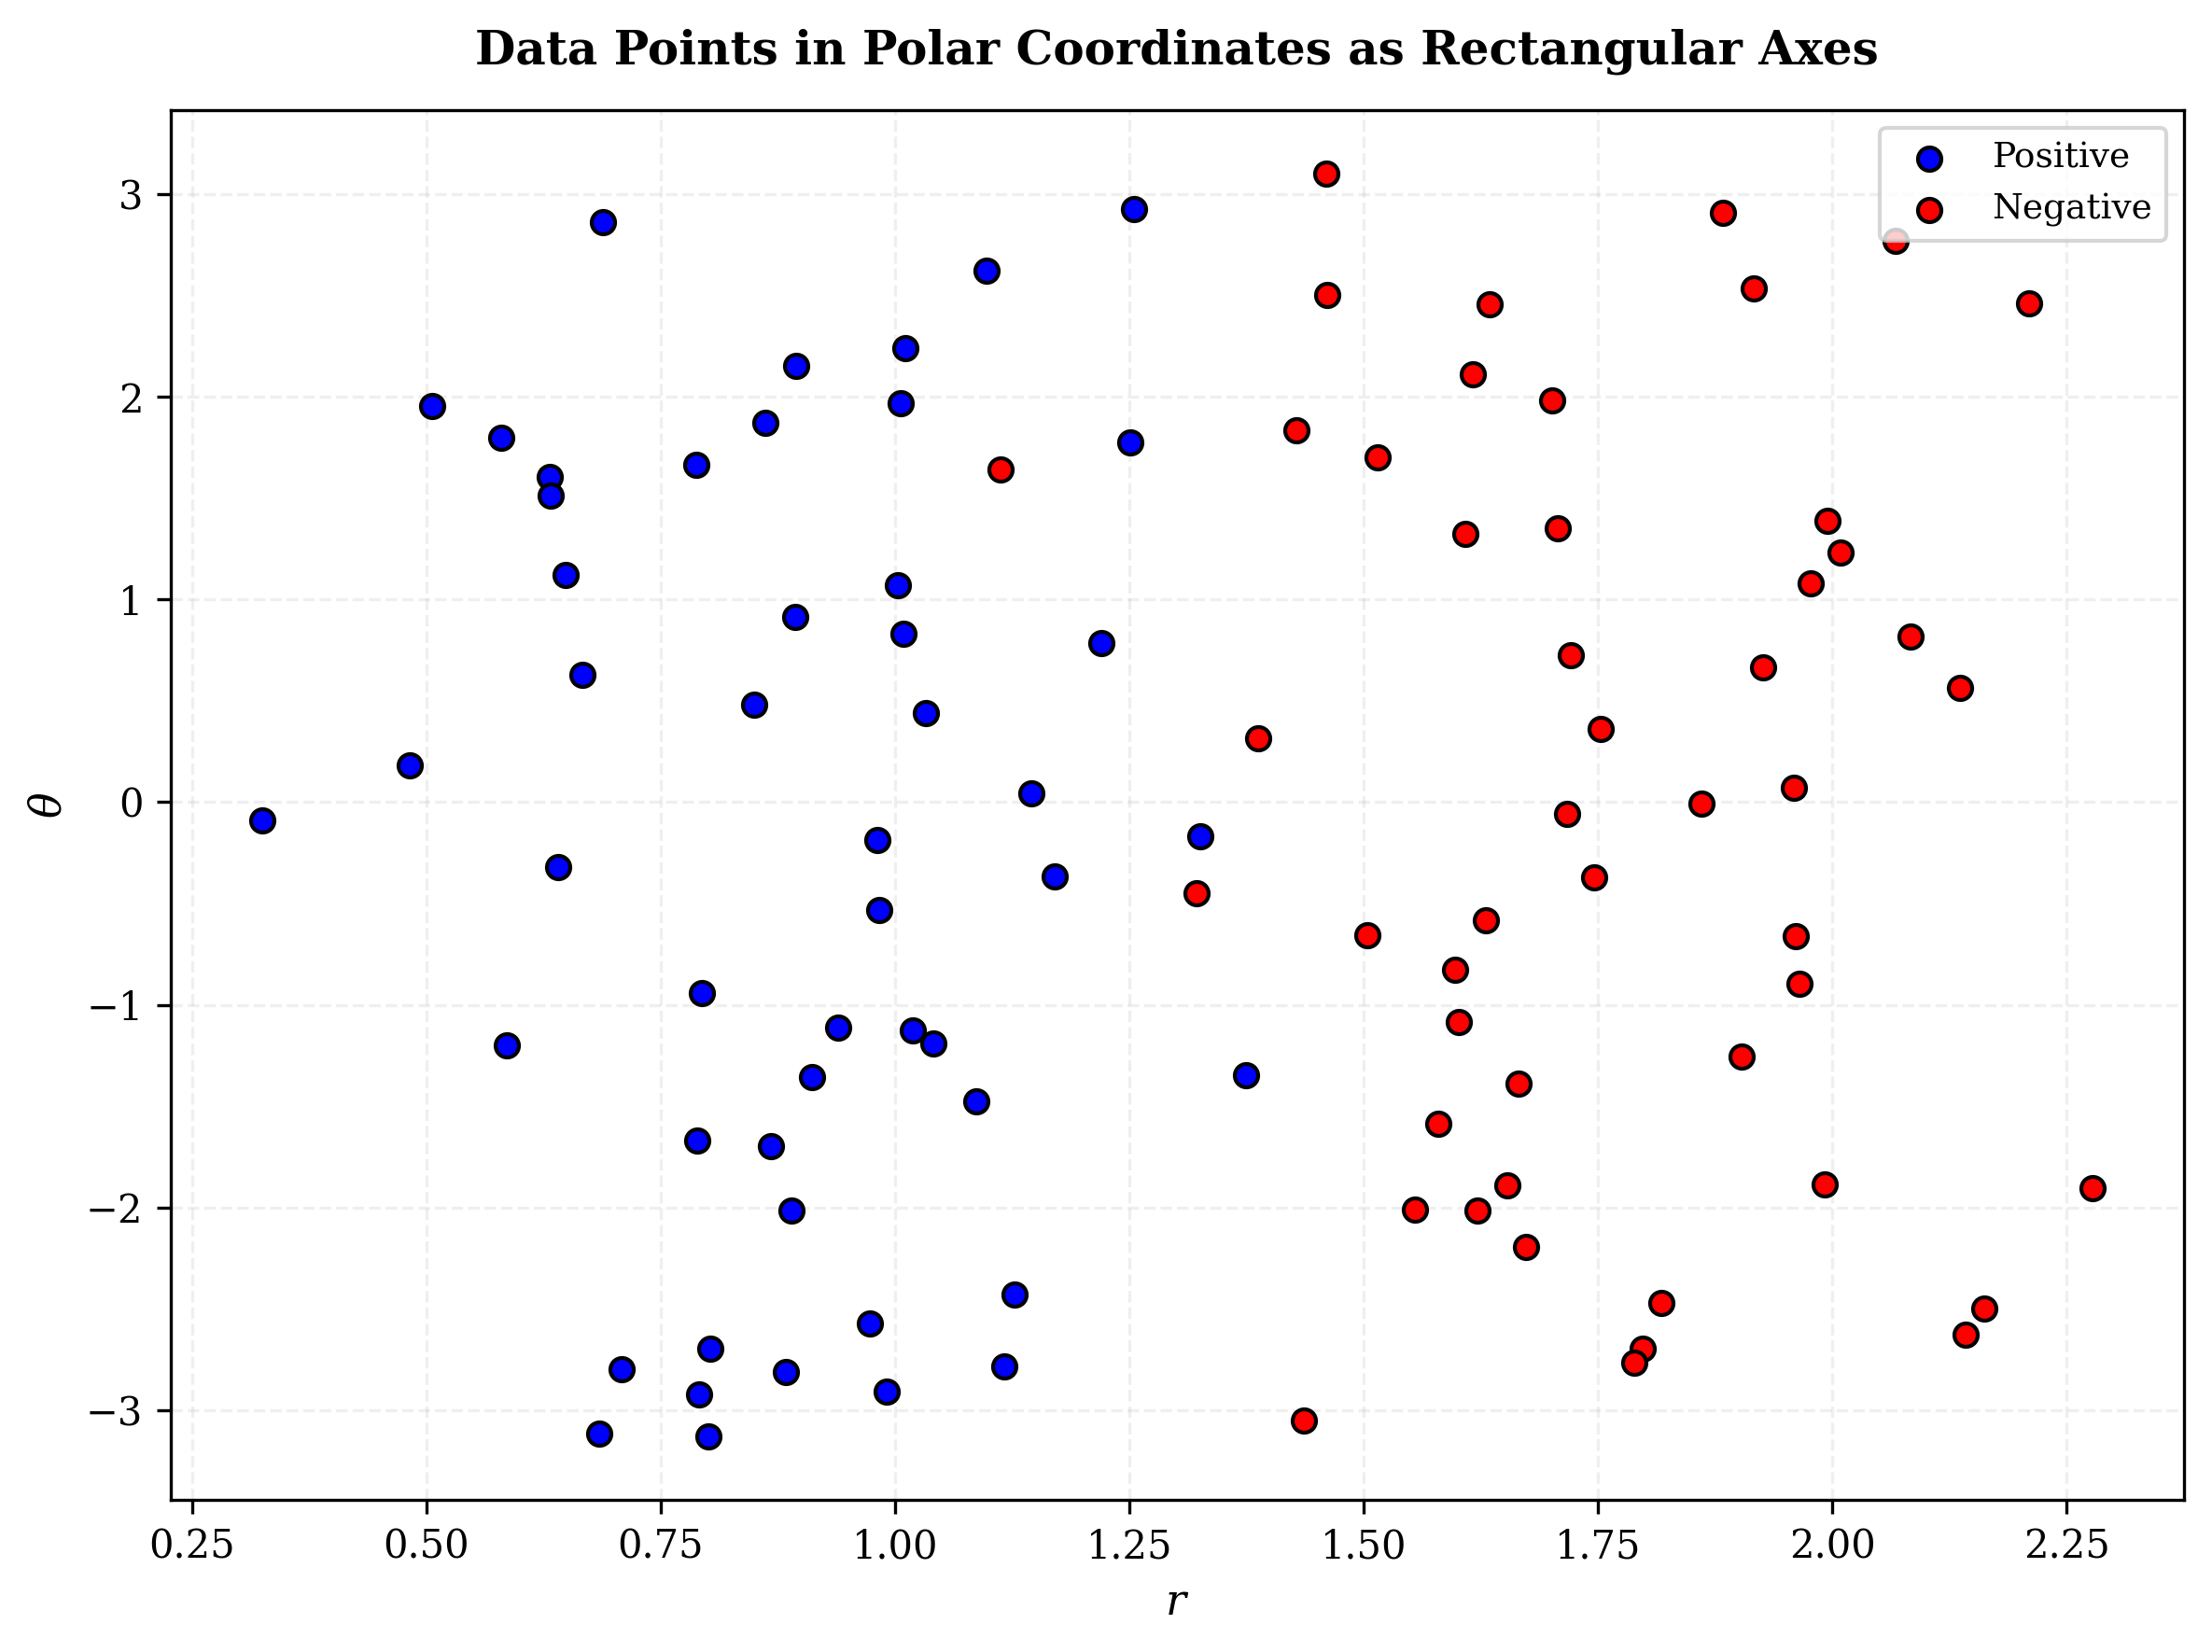

In [6]:
# Plotting data points in polar coordinates (but as rectangular axes)
polar_data_fig, polar_data_ax = plot_in_rectangular_coordinates(
    polar_dataset.X, polar_dataset.y, 
    title='Data Points in Polar Coordinates as Rectangular Axes',
    axis_x_label=r'$r$', axis_y_label=r'$\theta$',
)

display(polar_data_fig)

In [7]:
plot_manager.handle(polar_data_fig, name='polar_data_rectangular')

The classes become approximately separable along the radial axis, suggesting that a linear model may suffice in this representation.

## Feature Transformation: Elliptical Coordinates

Test whether elliptical symmetry enables more separability.

There is a family of elliptic coordinates each defined uniquely through a parameter (c)

In [8]:
# Transform data points into polar form
elliptic_dataset = dataset.transform(cartesian_to_elliptic)

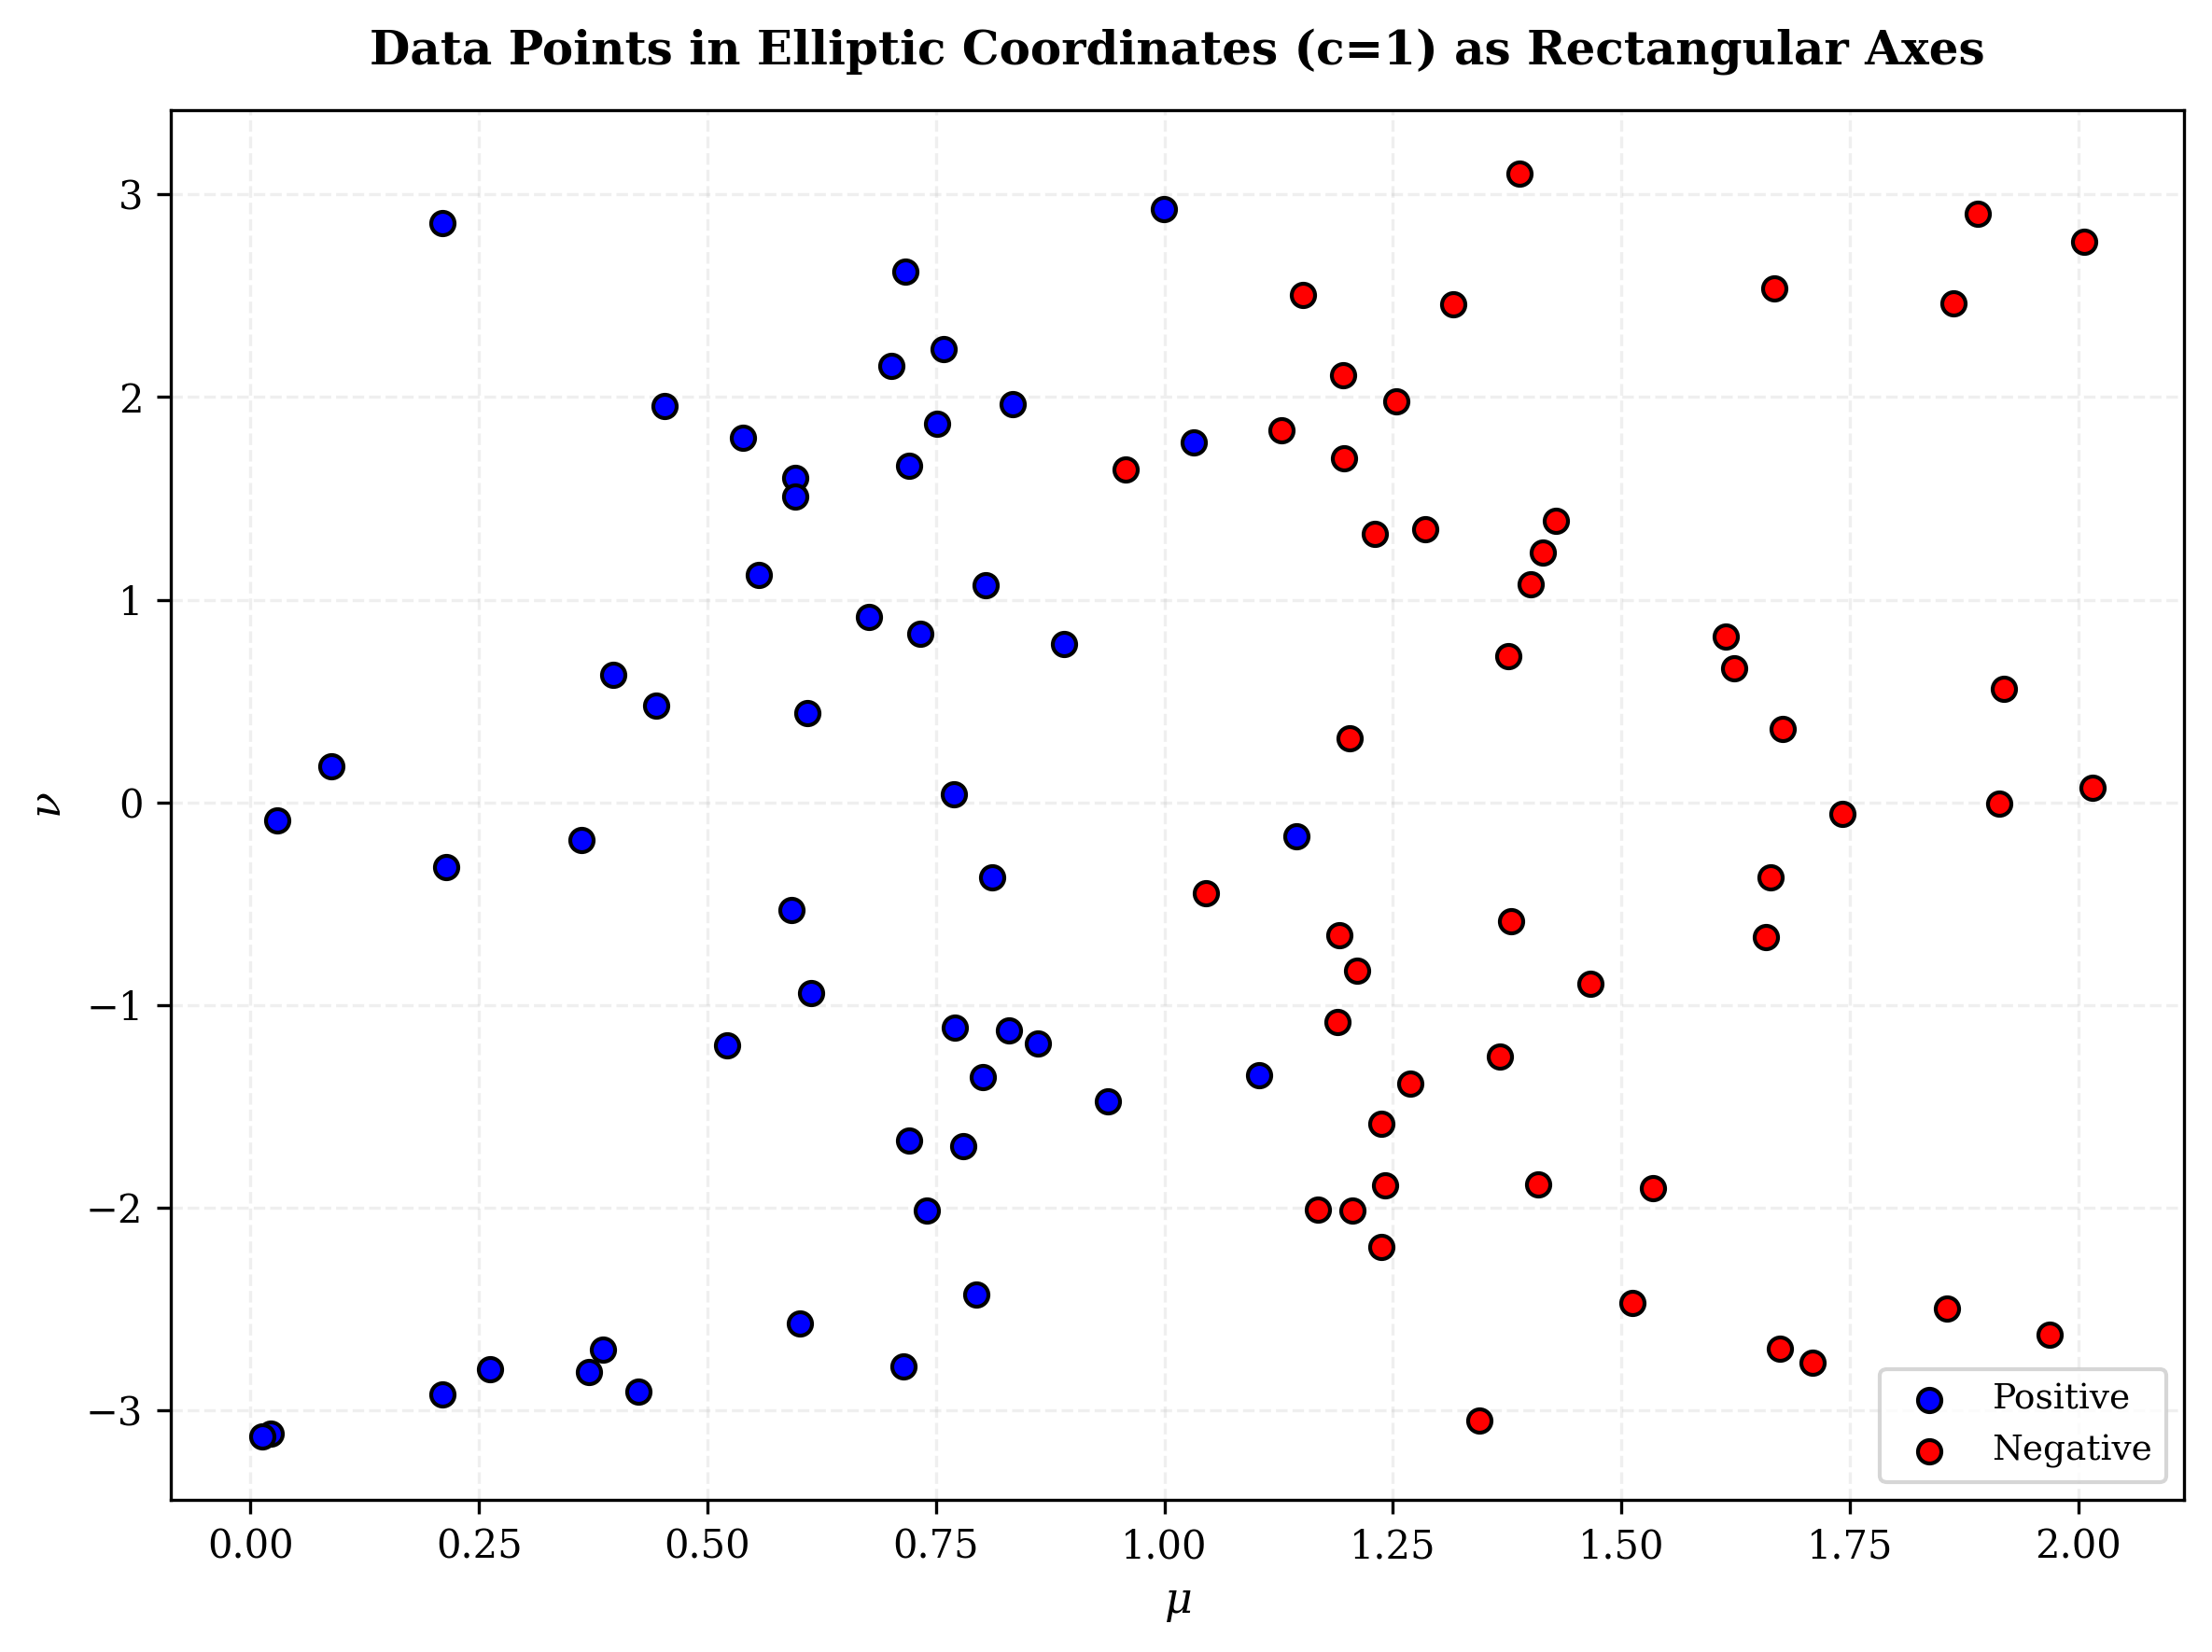

In [9]:
# Plotting data points in polar coordinates (but as rectangular axes)
elliptic_data_fig, elliptic_data_ax = plot_in_rectangular_coordinates(
    elliptic_dataset.X, elliptic_dataset.y, 
    title='Data Points in Elliptic Coordinates (c=1) as Rectangular Axes', 
    axis_x_label=r'$\mu$', axis_y_label=r'$\nu$'
)

display(elliptic_data_fig)

In [10]:
plot_manager.handle(elliptic_data_fig, name='elliptic_data_rectangular')

The decision boundary also looks close to a straight line in these particular elliptical coordinate selection, very similar to what is obtained in the polar representation.

## Feature Transformation: Dual Axis Angular Coordinate

Parametric equation of an ellipse (t as the angle): x(t) = a • cos(t), y(t) = b • sin(t)

Distance from origin: r(t) = a^2 • cos^2(t) + b^2 • sin^2(t)

Linearized kernel for logistic regression: r(t) = a^2 • cos^2(t) + b^2 • (1 - cos^2(t)) = (b^2) + (a^2 - b^2) cos^2(t) satisfies natural kernel form a' + b'X - c'R under radial variable and naturally engineered variable X=cos^2(t)

Engineered variable satisfies suggested two-fold symmetry over coordinate axes

In [11]:
# Transform data points from polar into curvilinear form
cos_sqd_dataset = polar_dataset.transform(
    polar_to_curvilinear_cos2theta, new_coordinate_system='curvilinear',
    new_feature_mapping={'x1': 'r', 'x2': 'cos2()'}
)

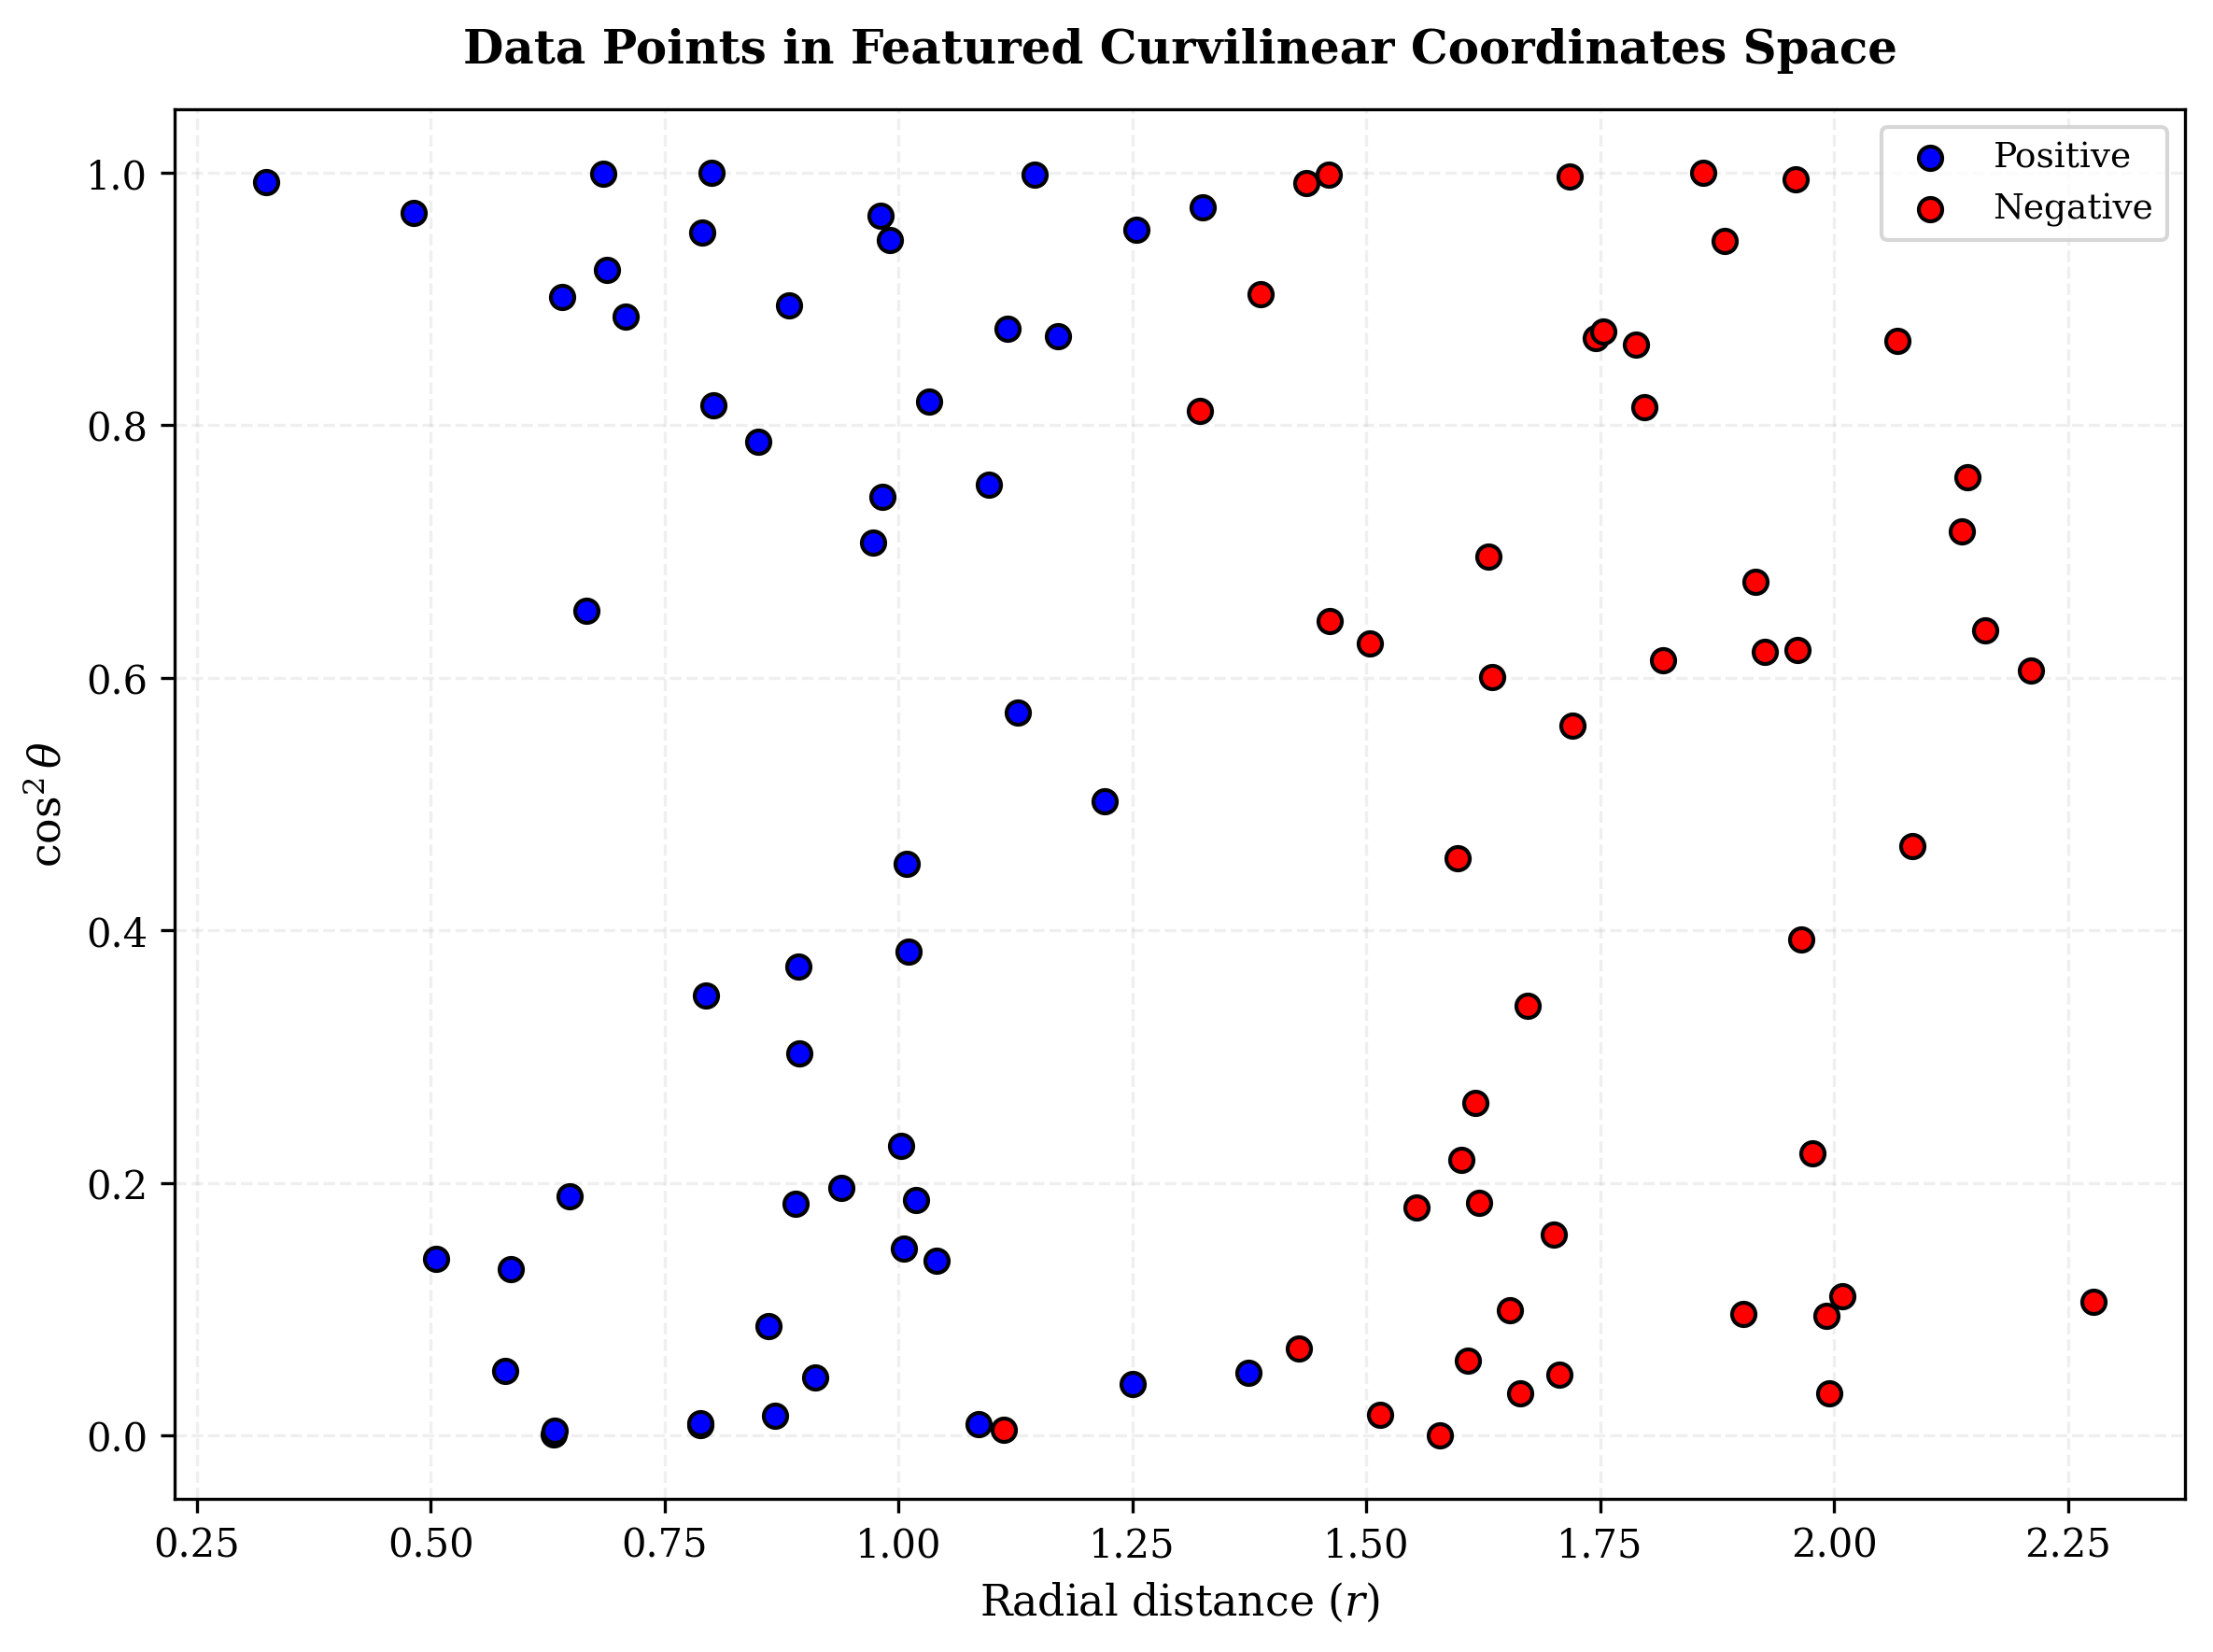

In [12]:
# Plotting data points in polar coordinates (but as rectangular axes)
cos_sqd_data_fig, cos_sqd_data_ax = plot_in_rectangular_coordinates(
    cos_sqd_dataset.X, cos_sqd_dataset.y, 
    title=r'Data Points in Featured Curvilinear Coordinates Space',
    axis_x_label=r'Radial distance ($r$)', axis_y_label=r'$\cos^2{\theta}$'
)

display(cos_sqd_data_fig)

In [13]:
plot_manager.handle(cos_sqd_data_fig, name='cos2_data_rectangular')

------------------------------

# Fitness Feasibility

In [14]:
# Create a Cartesian meshgrid to plot decision boundaries
grid_x, grid_y, grid_cartesian = create_meshgrid(dataset.X, resolution=500)

## Logistic Regression on Polar Coordinates

In [15]:
lr_polar_model = train_logistic_regression(polar_dataset.X, polar_dataset.y)

In [16]:
lr_polar_metrics = ModelMetrics('Logistic Regression', 'Polar', polar_dataset.y, lr_polar_model.predict(polar_dataset.X))
lr_polar_metrics.compute_metrics()
lr_polar_metrics.to_pandas()

,accuracy,precision,recall,f1
0,0.969697,0.960784,0.98,0.970297


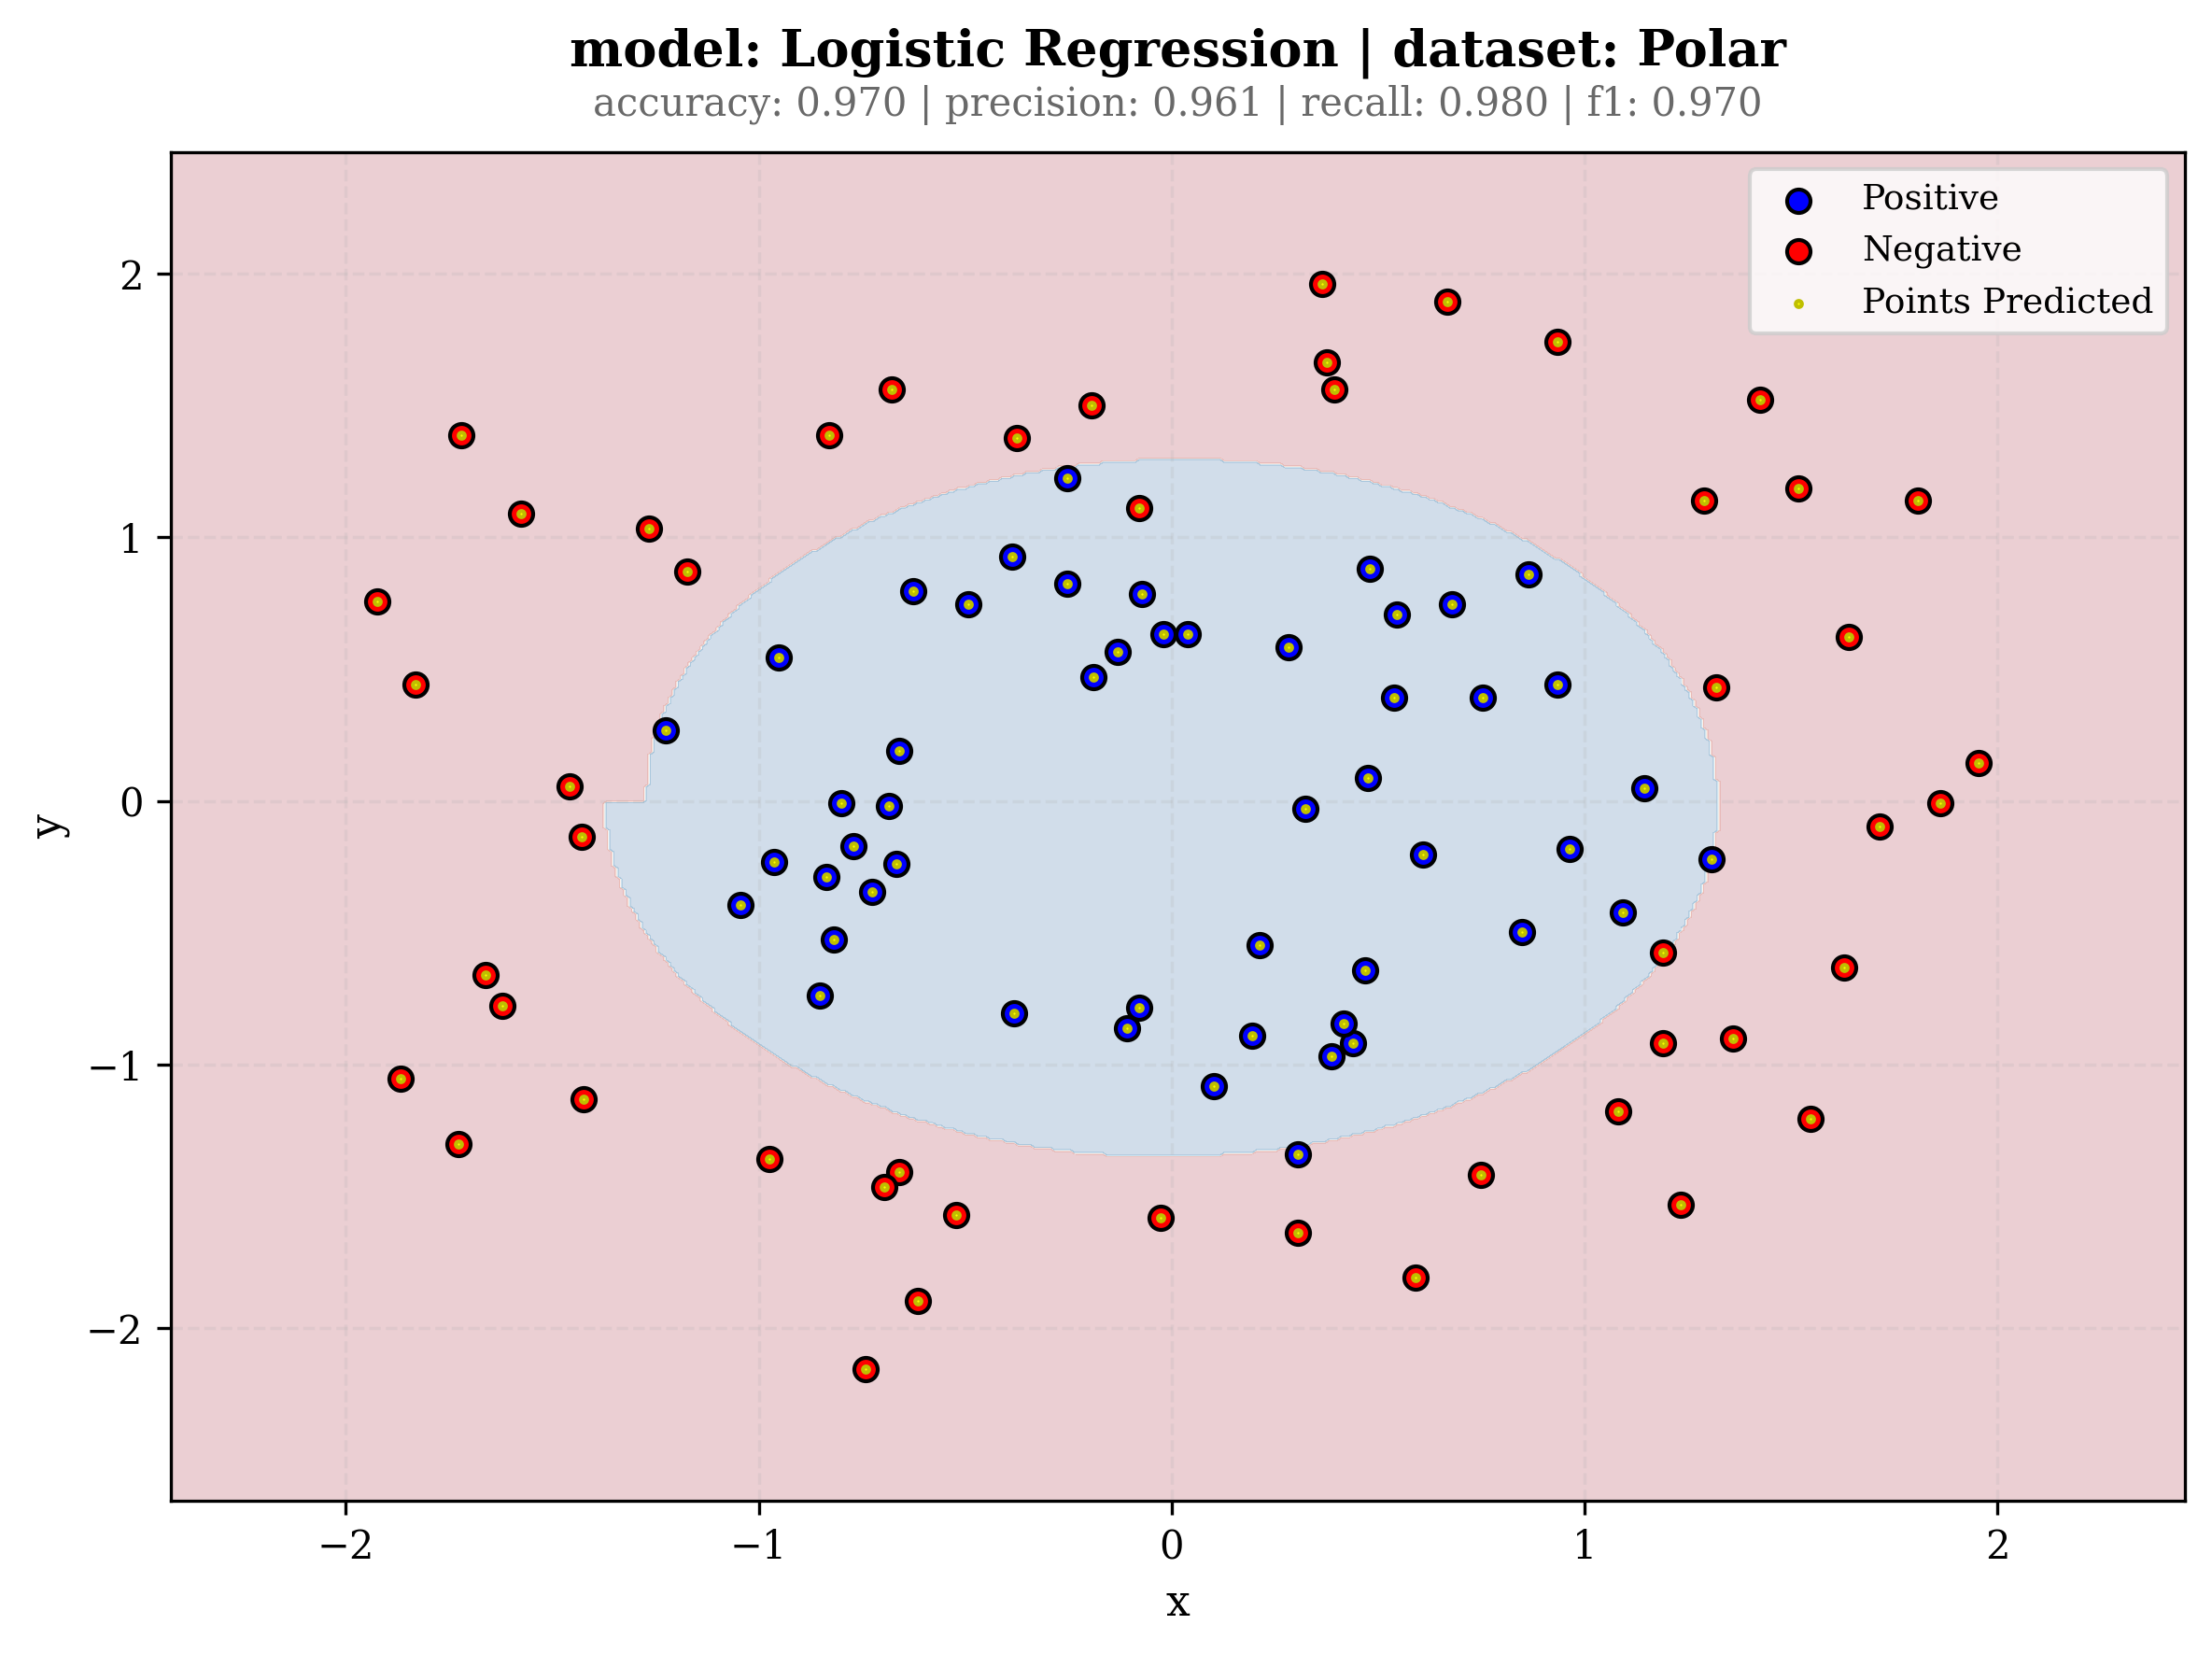

In [17]:
# Transform meshgrid into polar grid
grid_polar = cartesian_to_polar(grid_x.ravel(), grid_y.ravel())

fig, ax = plot_decision_boundary(
    model=lr_polar_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=f'model: {lr_polar_metrics.metadata['model']} | dataset: {lr_polar_metrics.metadata['dataset']}',
    metrics=lr_polar_metrics.to_dict(),
    axis_x_label='x',
    axis_y_label='y'
)
display(fig)

In [18]:
plot_manager.handle(fig, name='polar_logi_regr_rectangular')

## Logistic Regression on Elliptic Coordinates

In [19]:
lr_elliptic_model = train_logistic_regression(elliptic_dataset.X, elliptic_dataset.y)

In [20]:
lr_elliptic_metrics = ModelMetrics('Logistic Regression', 'Elliptic', elliptic_dataset.y, lr_elliptic_model.predict(elliptic_dataset.X))
lr_elliptic_metrics.compute_metrics()
lr_elliptic_metrics.to_pandas()

,accuracy,precision,recall,f1
0,0.959596,0.979167,0.94,0.959184


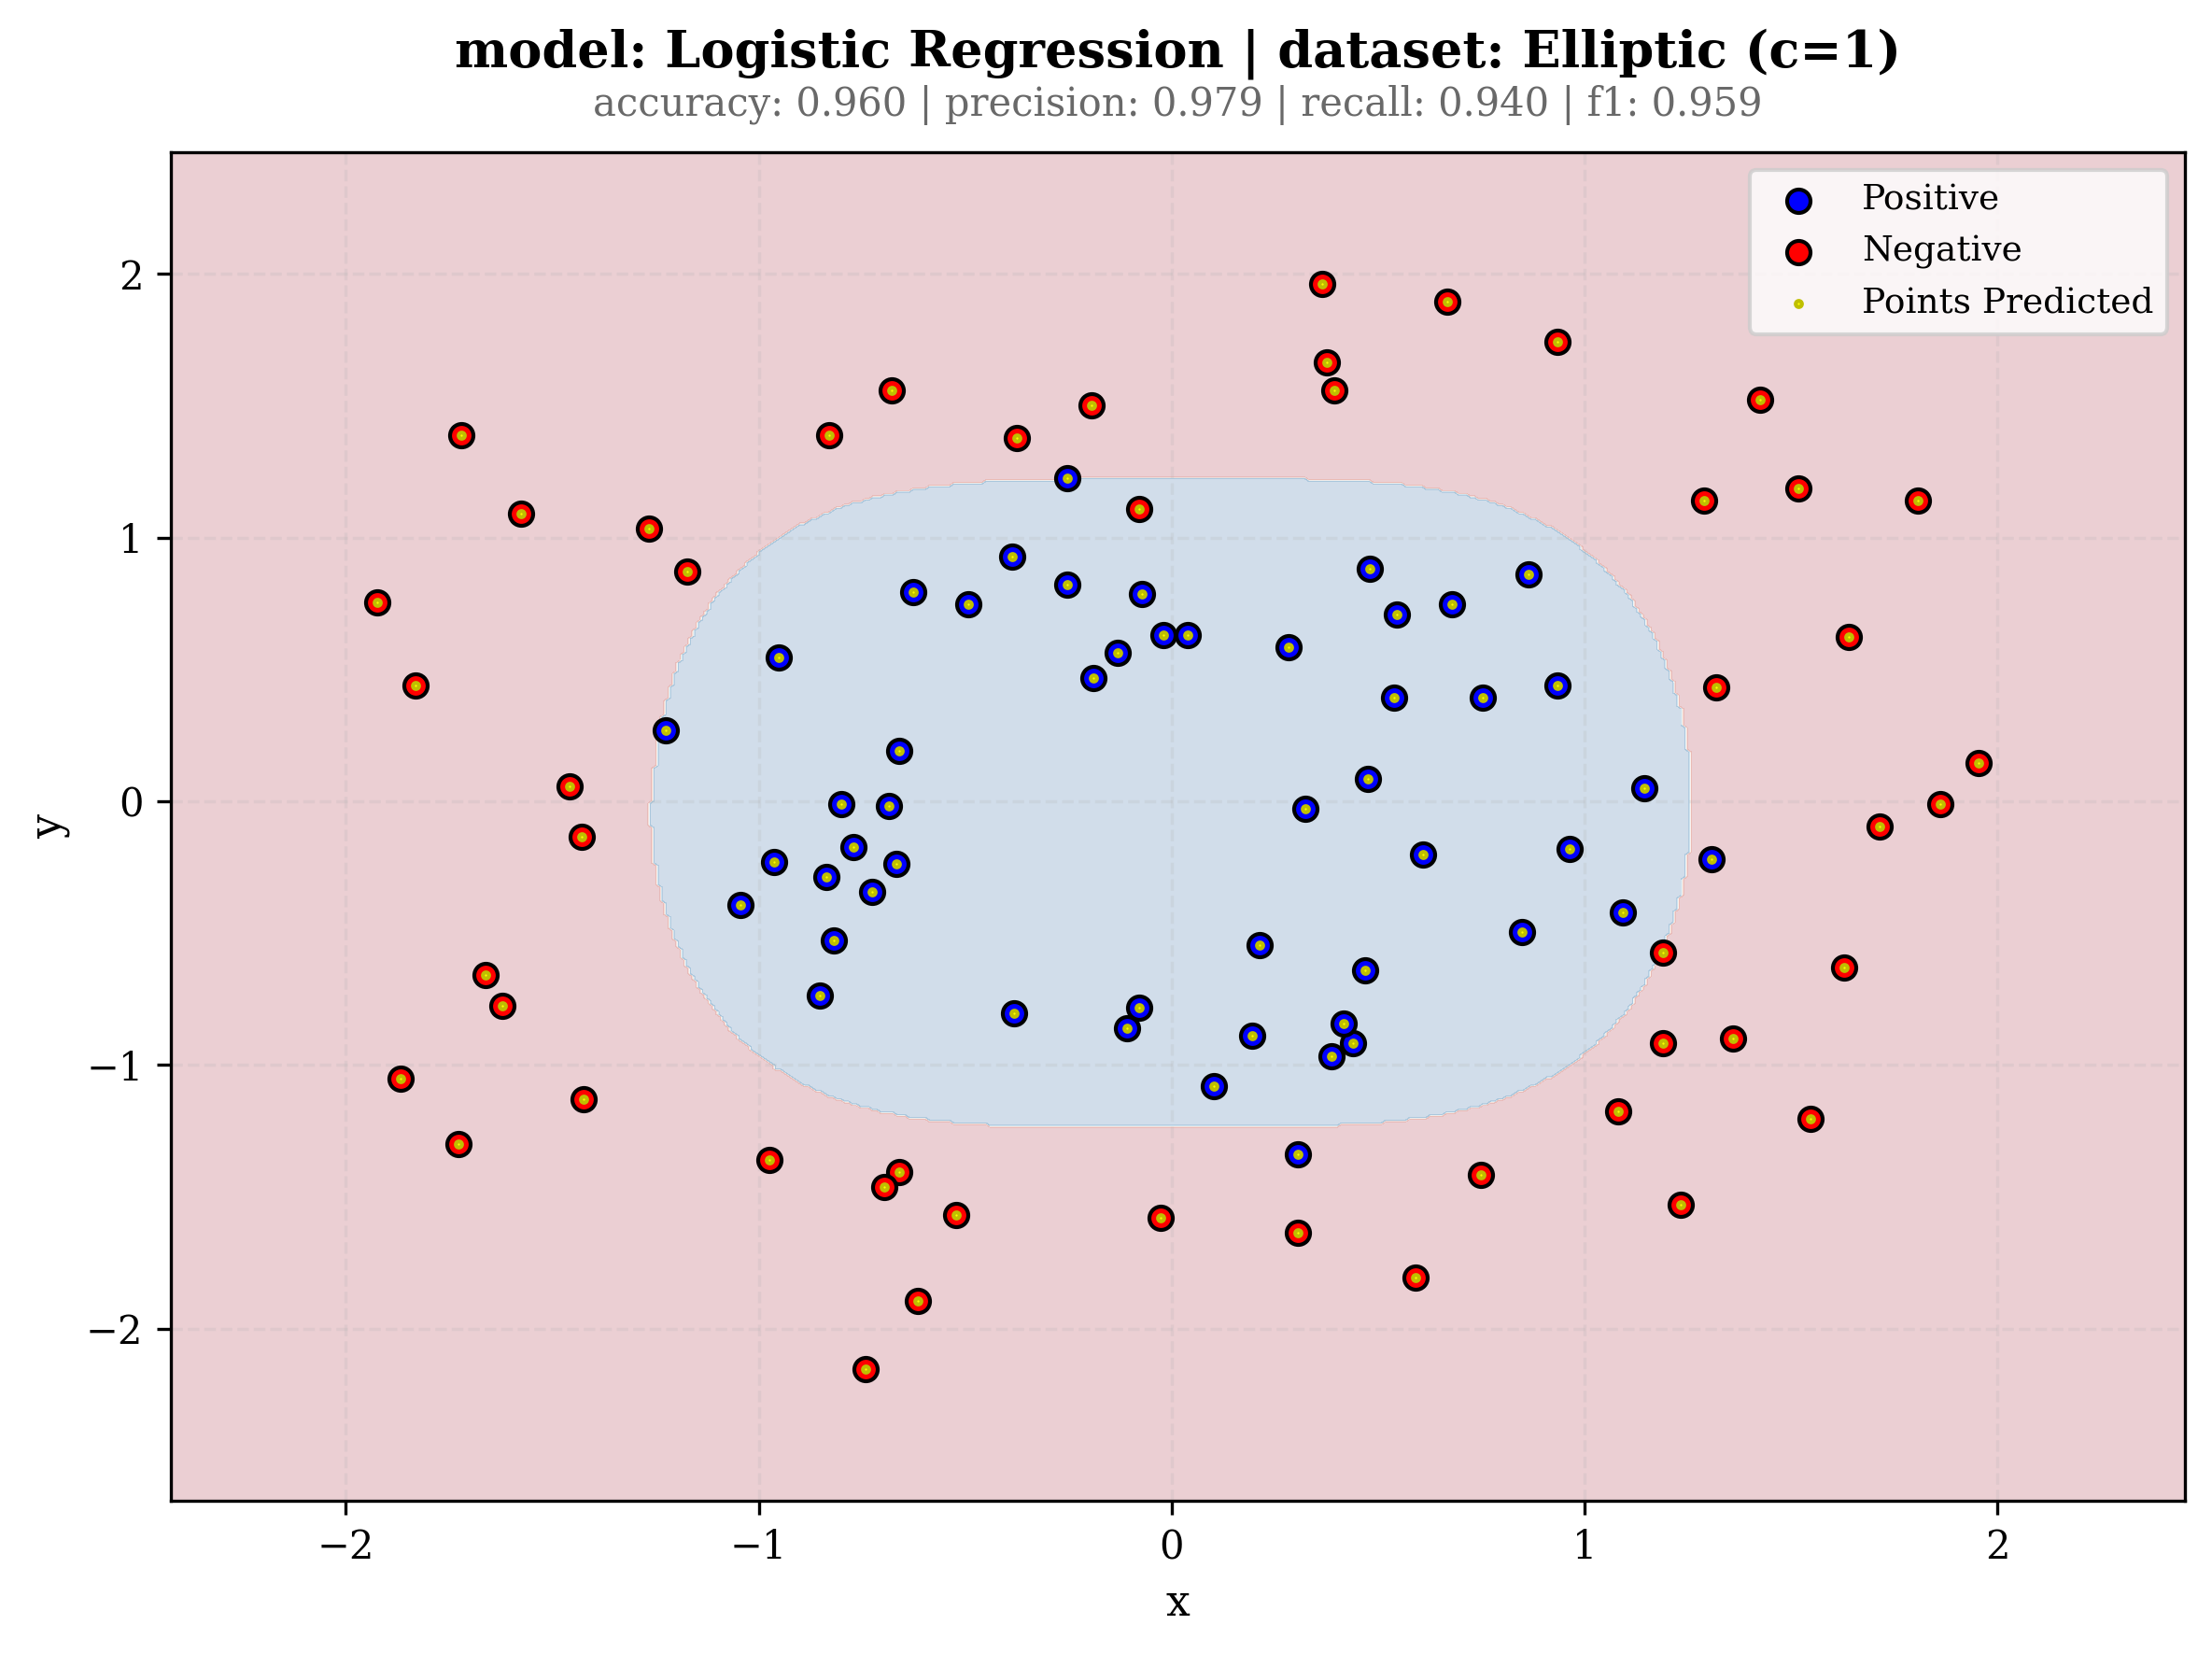

In [21]:
# elliptic coordinates (c=1) grid for decision boundary evaluation
grid_u = np.arccosh((1/(2*1)) * (np.sqrt((grid_x**2 + 1**2)**2 + grid_y**2) + np.sqrt((grid_x**2 - 1**2)**2 + grid_y**2)))
grid_v = np.arctan2(grid_y, grid_x)
grid_elliptic = pd.DataFrame({'x1': grid_u.ravel(), 'x2': grid_v.ravel()})

fig, ax = plot_decision_boundary(
    model=lr_elliptic_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_elliptic, grid_x=grid_x, grid_y=grid_y,
    title=f'model: {lr_elliptic_metrics.metadata['model']} | dataset: Elliptic (c=1)',
    metrics=lr_elliptic_metrics.to_dict(),
    axis_x_label='x',
    axis_y_label='y'
)

display(fig)

In [22]:
plot_manager.handle(fig, name='elliptic_logi_regr_rectangular')

# Logistic Regression on Engineered Featured Curvilinear Coordinates

In [23]:
# Transform polar into curvilinear grid
grid_cos_sqd = pd.DataFrame({ 'x1': grid_polar['x1'], 'x2': np.cos(grid_polar['x2'])**2})

In [24]:
lr_cos_sqd_model = train_logistic_regression(cos_sqd_dataset.X, cos_sqd_dataset.y)

In [25]:
lr_cos_sqd_metrics = ModelMetrics('Logistic Regression', 'cos^2(theta)', cos_sqd_dataset.y, lr_cos_sqd_model.predict(cos_sqd_dataset.X))
lr_cos_sqd_metrics.compute_metrics()
lr_cos_sqd_metrics.to_pandas()

,accuracy,precision,recall,f1
0,0.969697,0.960784,0.98,0.970297


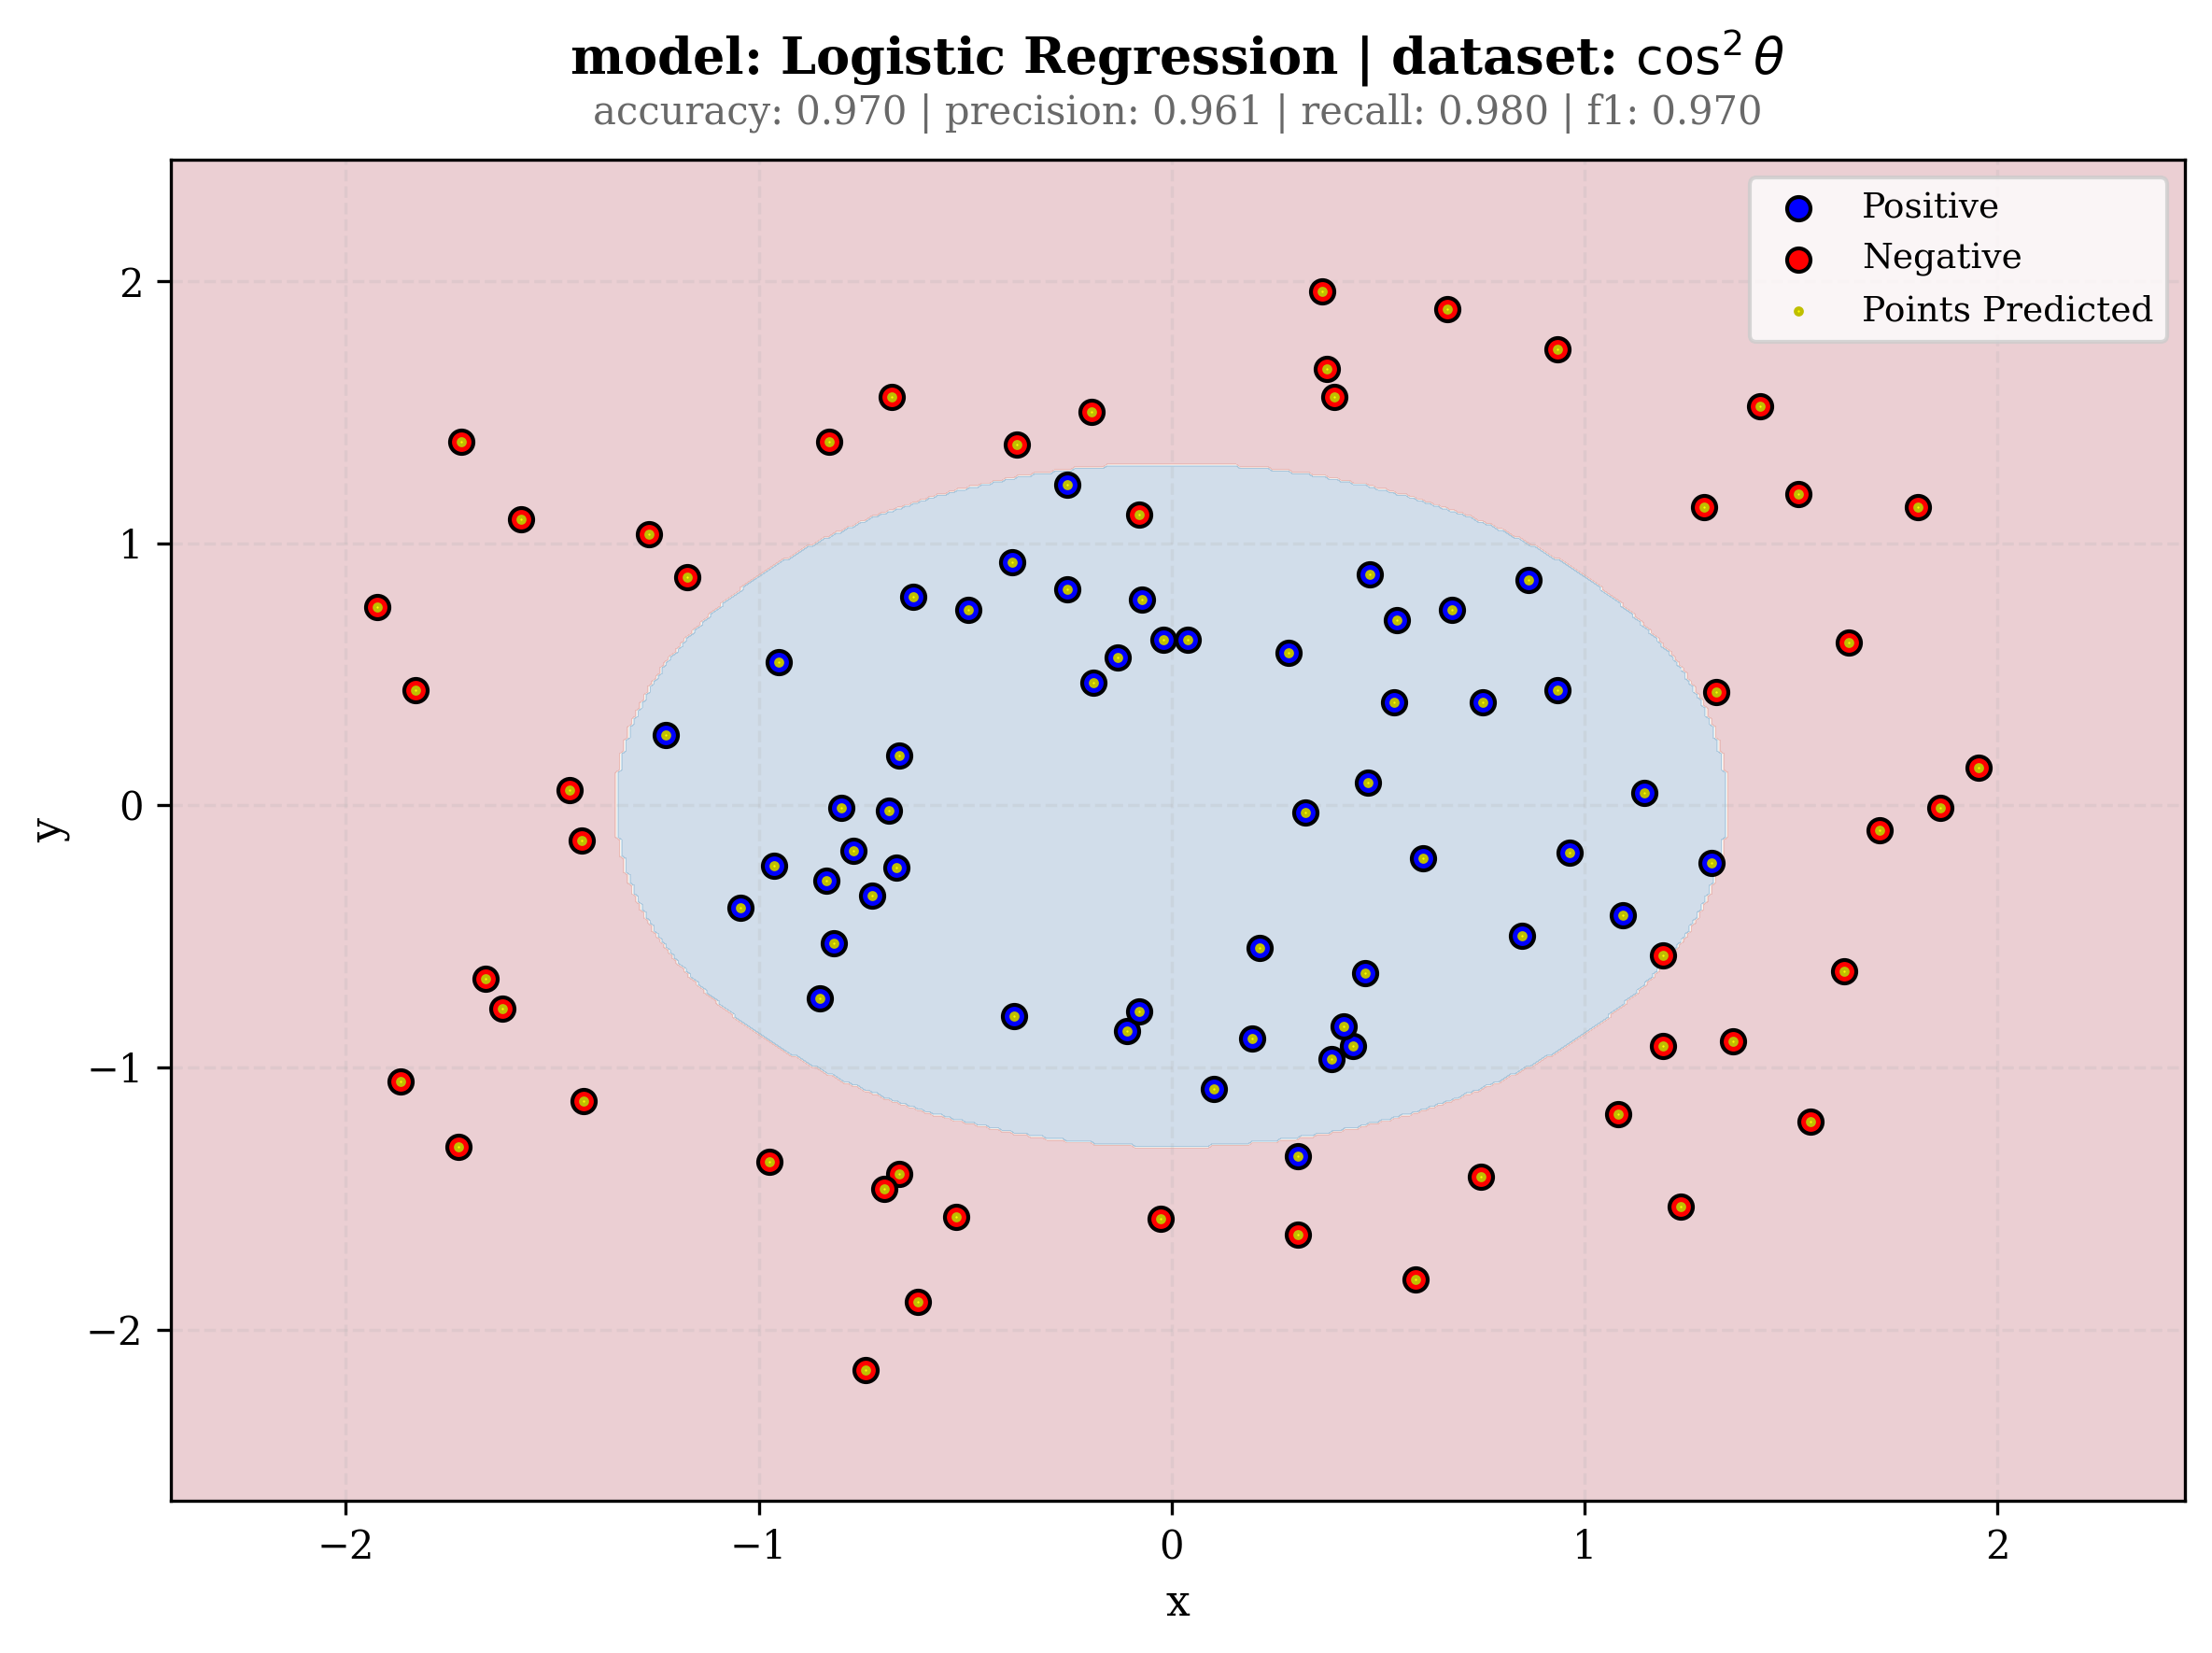

In [26]:
dataset_name = r'$\cos^2{\theta}$'

fig, ax = plot_decision_boundary(
    model=lr_cos_sqd_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_cos_sqd, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {lr_cos_sqd_metrics.metadata['model']} | dataset: {dataset_name}',
    metrics=lr_cos_sqd_metrics.to_dict(),
    axis_x_label='x',
    axis_y_label='y'
)

display(fig)

In [27]:
plot_manager.handle(fig, name='cos2_logi_regr_rectangular')

---------------------

## Complex Model Benchmark: Support Vector Machines

In [28]:
svm_model = train_svm(dataset.X, dataset.y)

In [29]:
svm_metrics = ModelMetrics(
    model_name='Support Vector Machine', dataset_name='Cartesian', 
    response=dataset.y, estimated_response=svm_model.predict(dataset.X)
)
svm_metrics.compute_metrics()
svm_metrics.to_pandas()

,accuracy,precision,recall,f1
0,0.969697,0.979592,0.96,0.969697


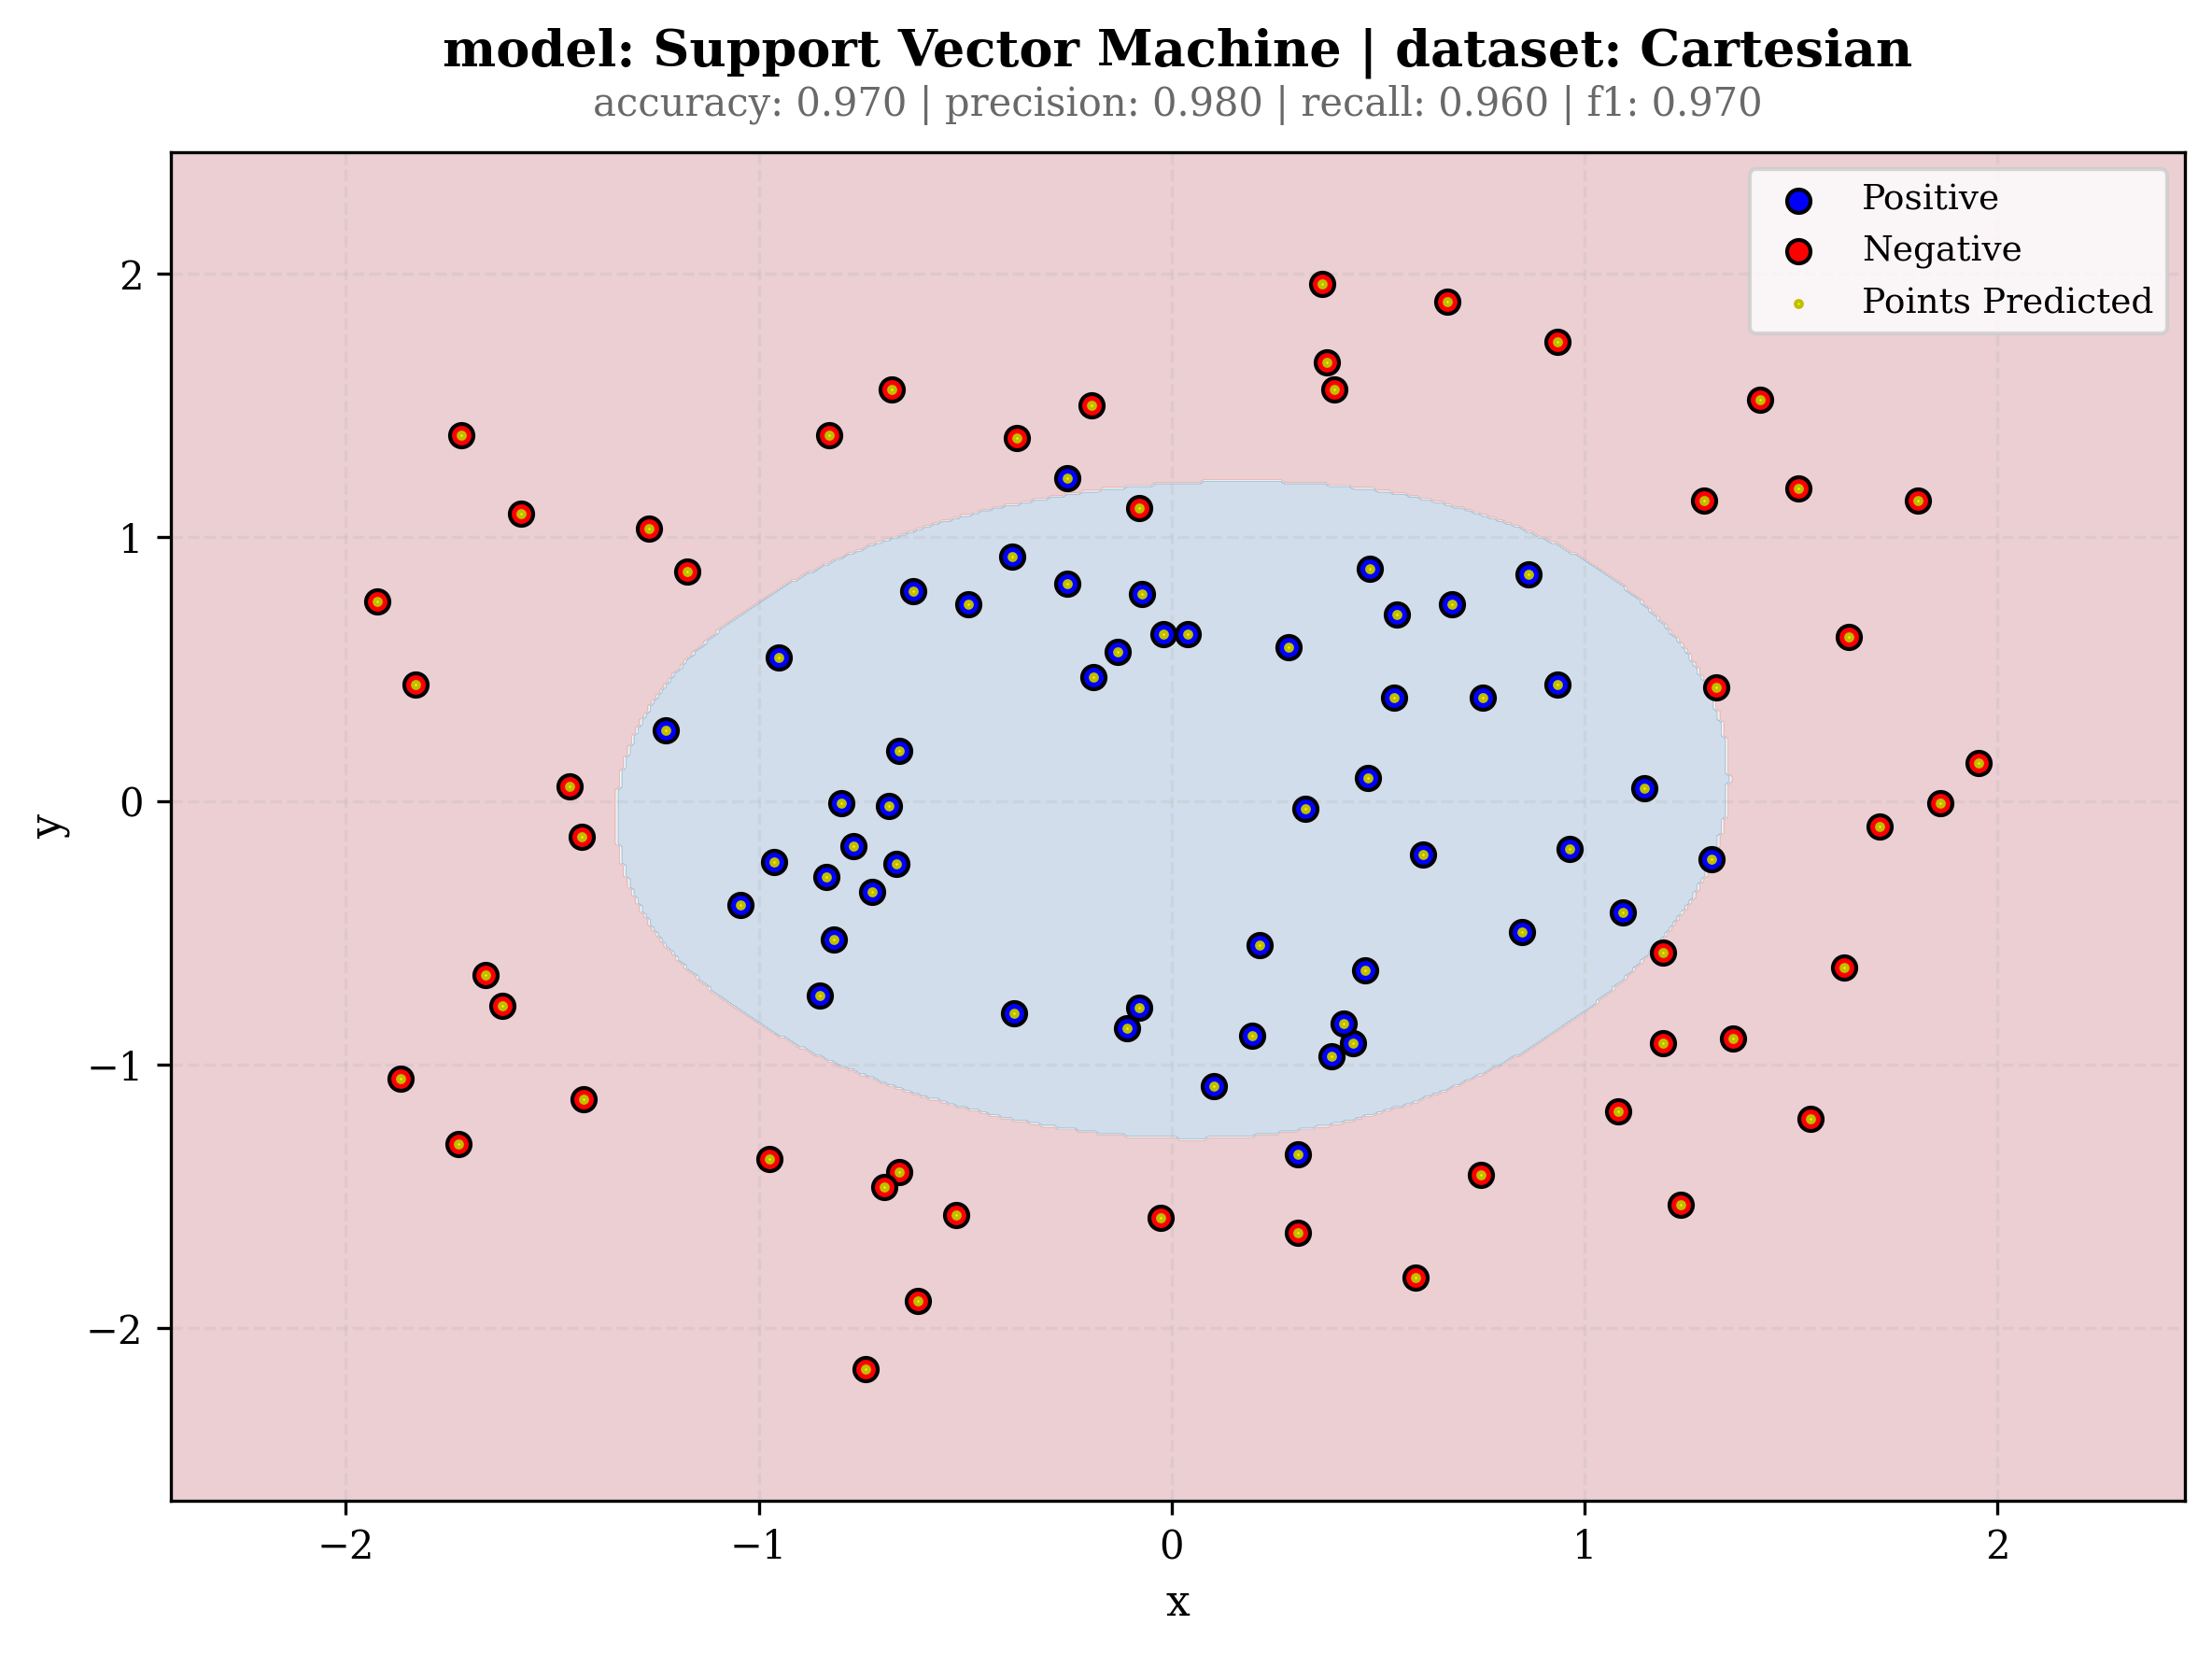

In [30]:
fig, ax = plot_decision_boundary(
    model=svm_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {svm_metrics.metadata['model']} | dataset: {svm_metrics.metadata['dataset']}',
    metrics=svm_metrics.to_dict(),
    axis_x_label='x',
    axis_y_label='y'
)

display(fig)

In [31]:
plot_manager.handle(cos_sqd_data_fig, name='svm_rectangular')

---------------------------------

# Evaluating Feature Importance of Polar Coordinates

- Mutual information
- Univariate and bivariate model comparisons
- Perturbation test

## Mutual Information

In [32]:
from sklearn.feature_selection import mutual_info_classif

In [33]:
for feature in dataset.X.columns:
    score = mutual_info_classif(dataset.X[[feature]], dataset.y, random_state=42)[0]
    print(feature, score)

x1 0.15089248089413365
x2 0.2353385202644156


In [34]:
for feature in polar_dataset.X.columns:
    score = mutual_info_classif(polar_dataset.X[[feature]], polar_dataset.y, random_state=42)[0]
    print(feature, score)

x1 0.6161099331344604
x2 0


In [35]:
for feature in elliptic_dataset.X.columns:
    score = mutual_info_classif(elliptic_dataset.X[[feature]], elliptic_dataset.y, random_state=42)[0]
    print(feature, score)

x1 0.6032624983652397
x2 0


In [36]:
for feature in cos_sqd_dataset.X.columns:
    score = mutual_info_classif(cos_sqd_dataset.X[[feature]], cos_sqd_dataset.y, random_state=42)[0]
    print(feature, score)

x1 0.6161099331344604
x2 0.06508750304370126


The dominant discriminative structure of the dataset is radial rather than angular, as shown by the substantially higher mutual information between radius and class label.

## Univariate and Bivariate Model Comparissons

In [37]:
from src.models.model_utilities import Model1DWrapper

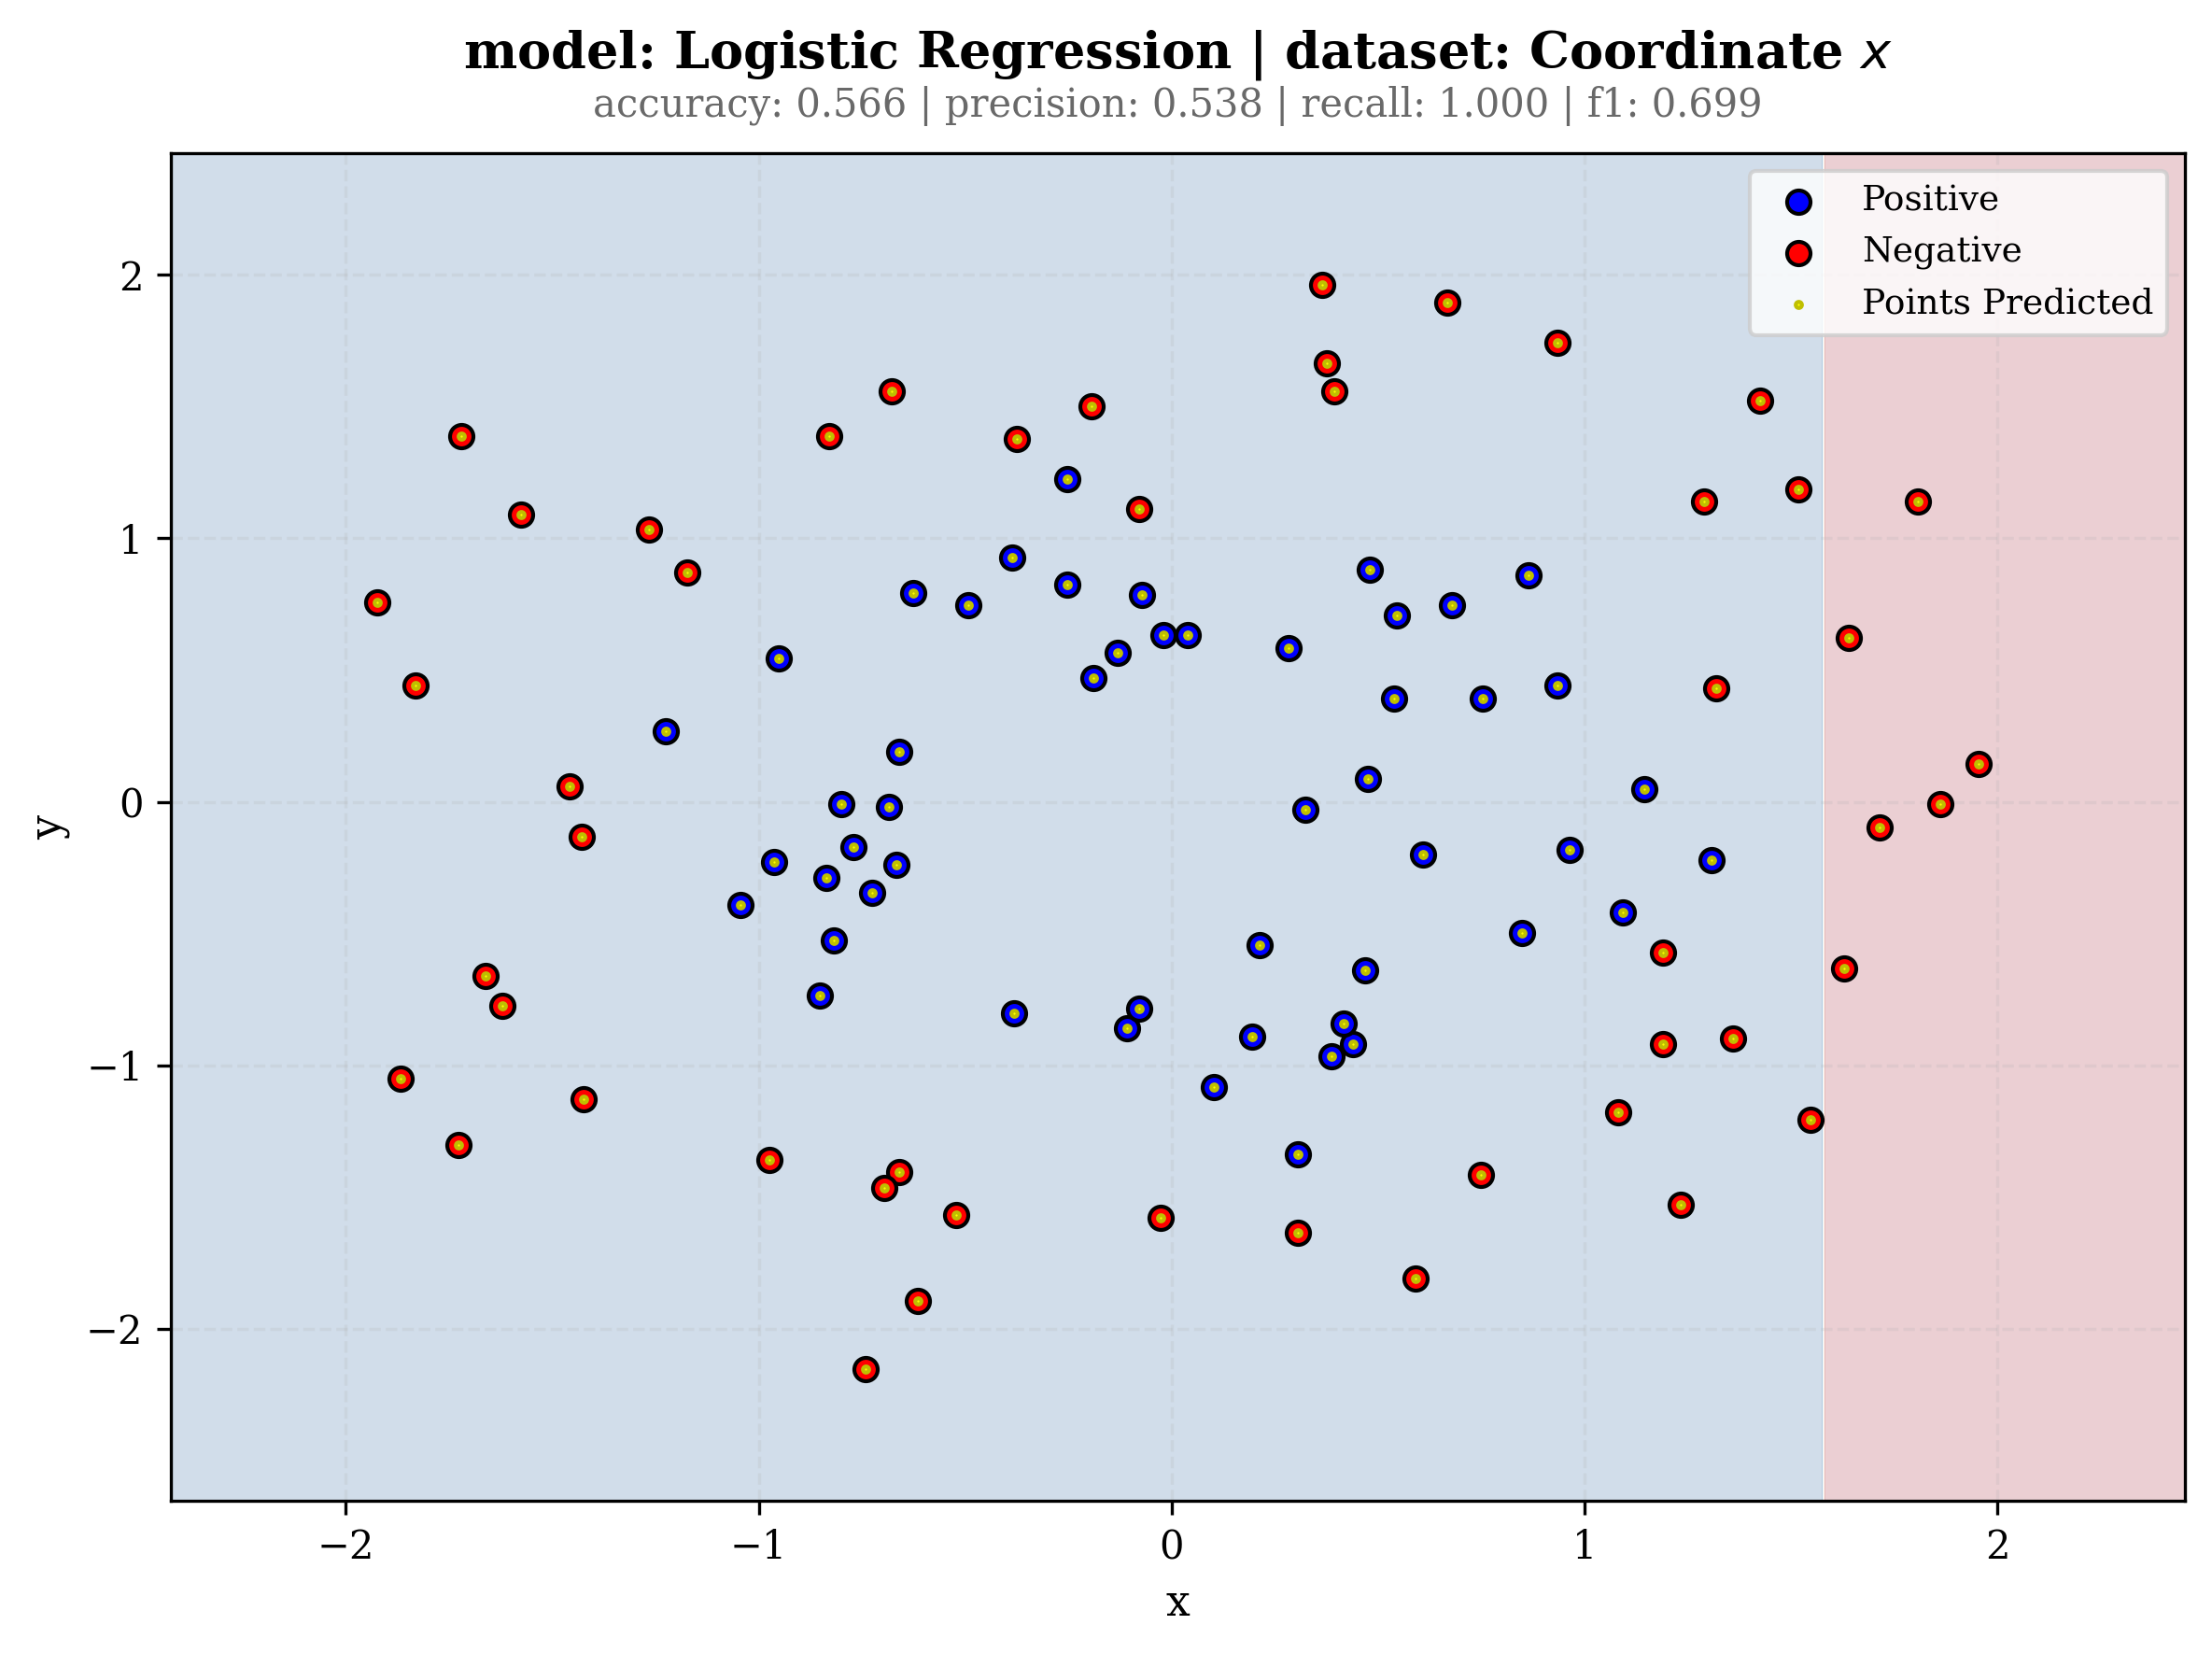

In [38]:
# Naive linear regression
vars_list = ['x1']
only_x = dataset.X[vars_list]
lr_model = train_logistic_regression(only_x, dataset.y)

lr_metrics = ModelMetrics('Logistic Regression', 'Cartesian', dataset.y, lr_model.predict(only_x))
lr_metrics.compute_metrics()

lr_wrapped_model = Model1DWrapper(trained_model=lr_model, vars_list=vars_list)

fig, ax = plot_decision_boundary(
    model=lr_wrapped_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {lr_metrics.metadata['model']} | dataset: Coordinate $x$',
    metrics=lr_metrics.to_dict(),
    axis_x_label='x',
    axis_y_label='y'
)

display(fig)

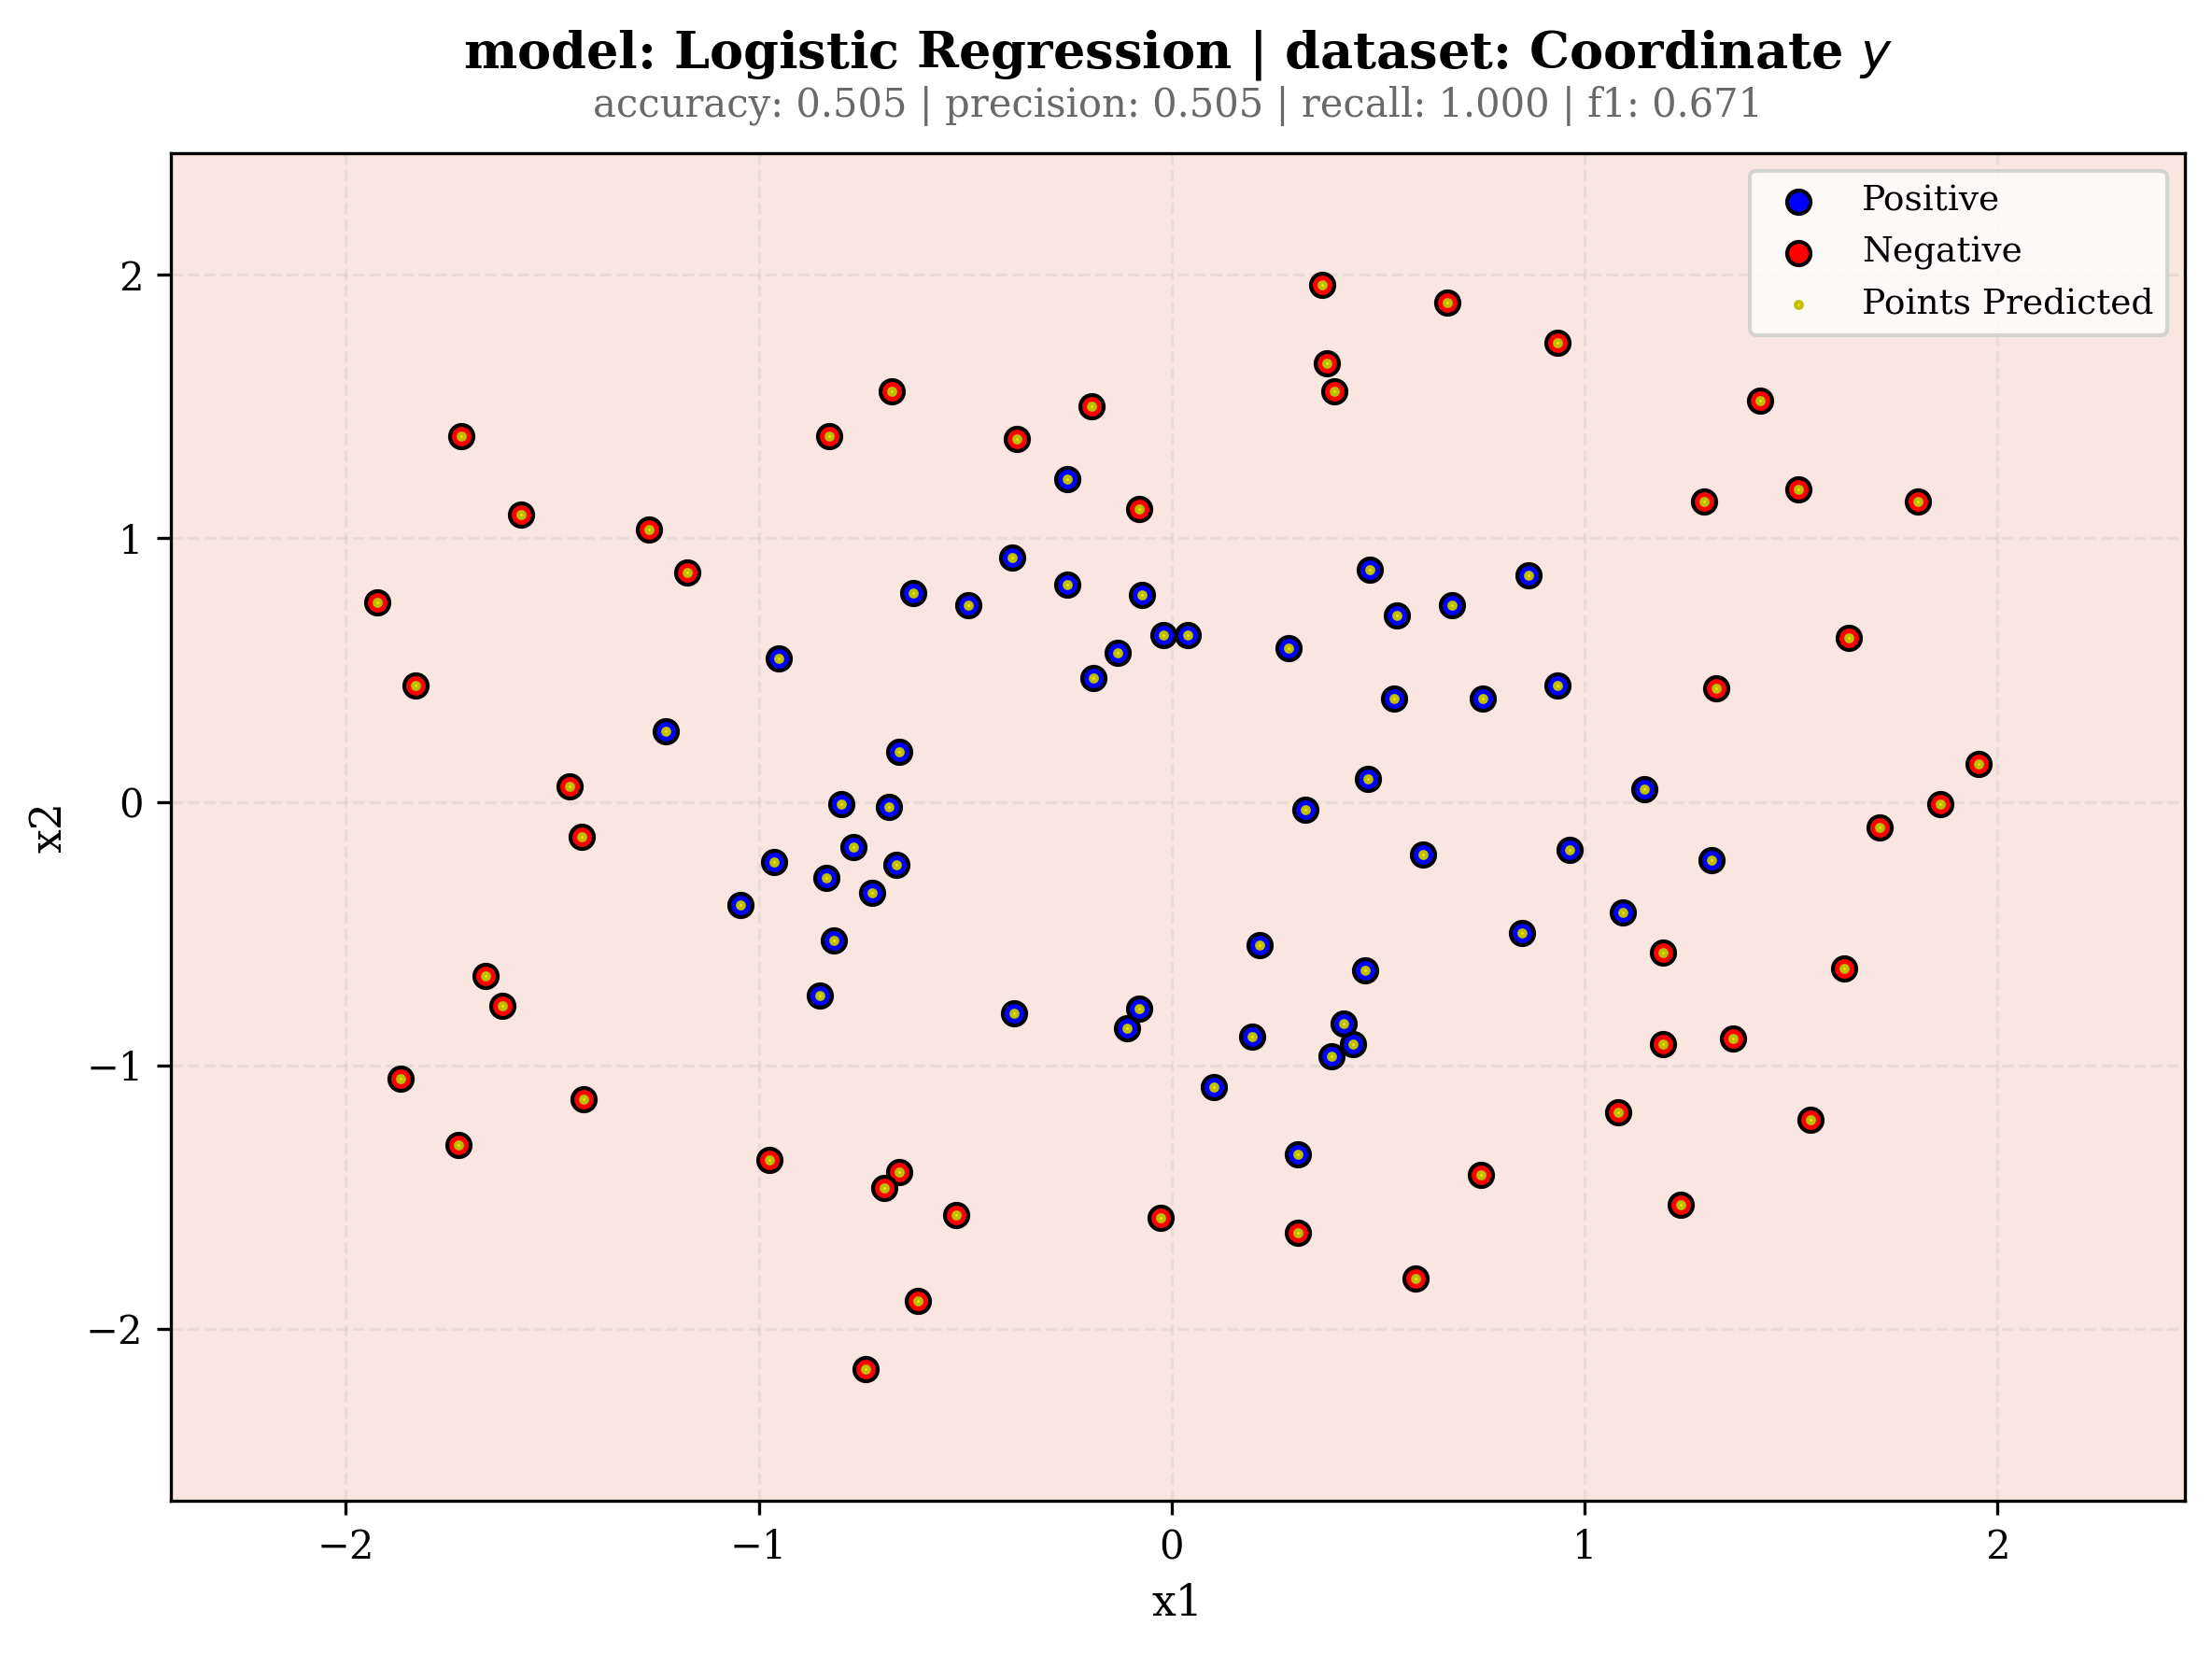

In [39]:
# Naive linear regression
vars_list = ['x2']
only_x = dataset.X[vars_list]
lr_model = train_logistic_regression(only_x, dataset.y)

lr_metrics = ModelMetrics('Logistic Regression', 'Cartesian', dataset.y, lr_model.predict(only_x))
lr_metrics.compute_metrics()

lr_wrapped_model = Model1DWrapper(trained_model=lr_model, vars_list=vars_list)

fig, ax = plot_decision_boundary(
    model=lr_wrapped_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_cartesian, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {lr_metrics.metadata['model']} | dataset: Coordinate $y$',
    metrics=lr_metrics.to_dict(),
)

display(fig)

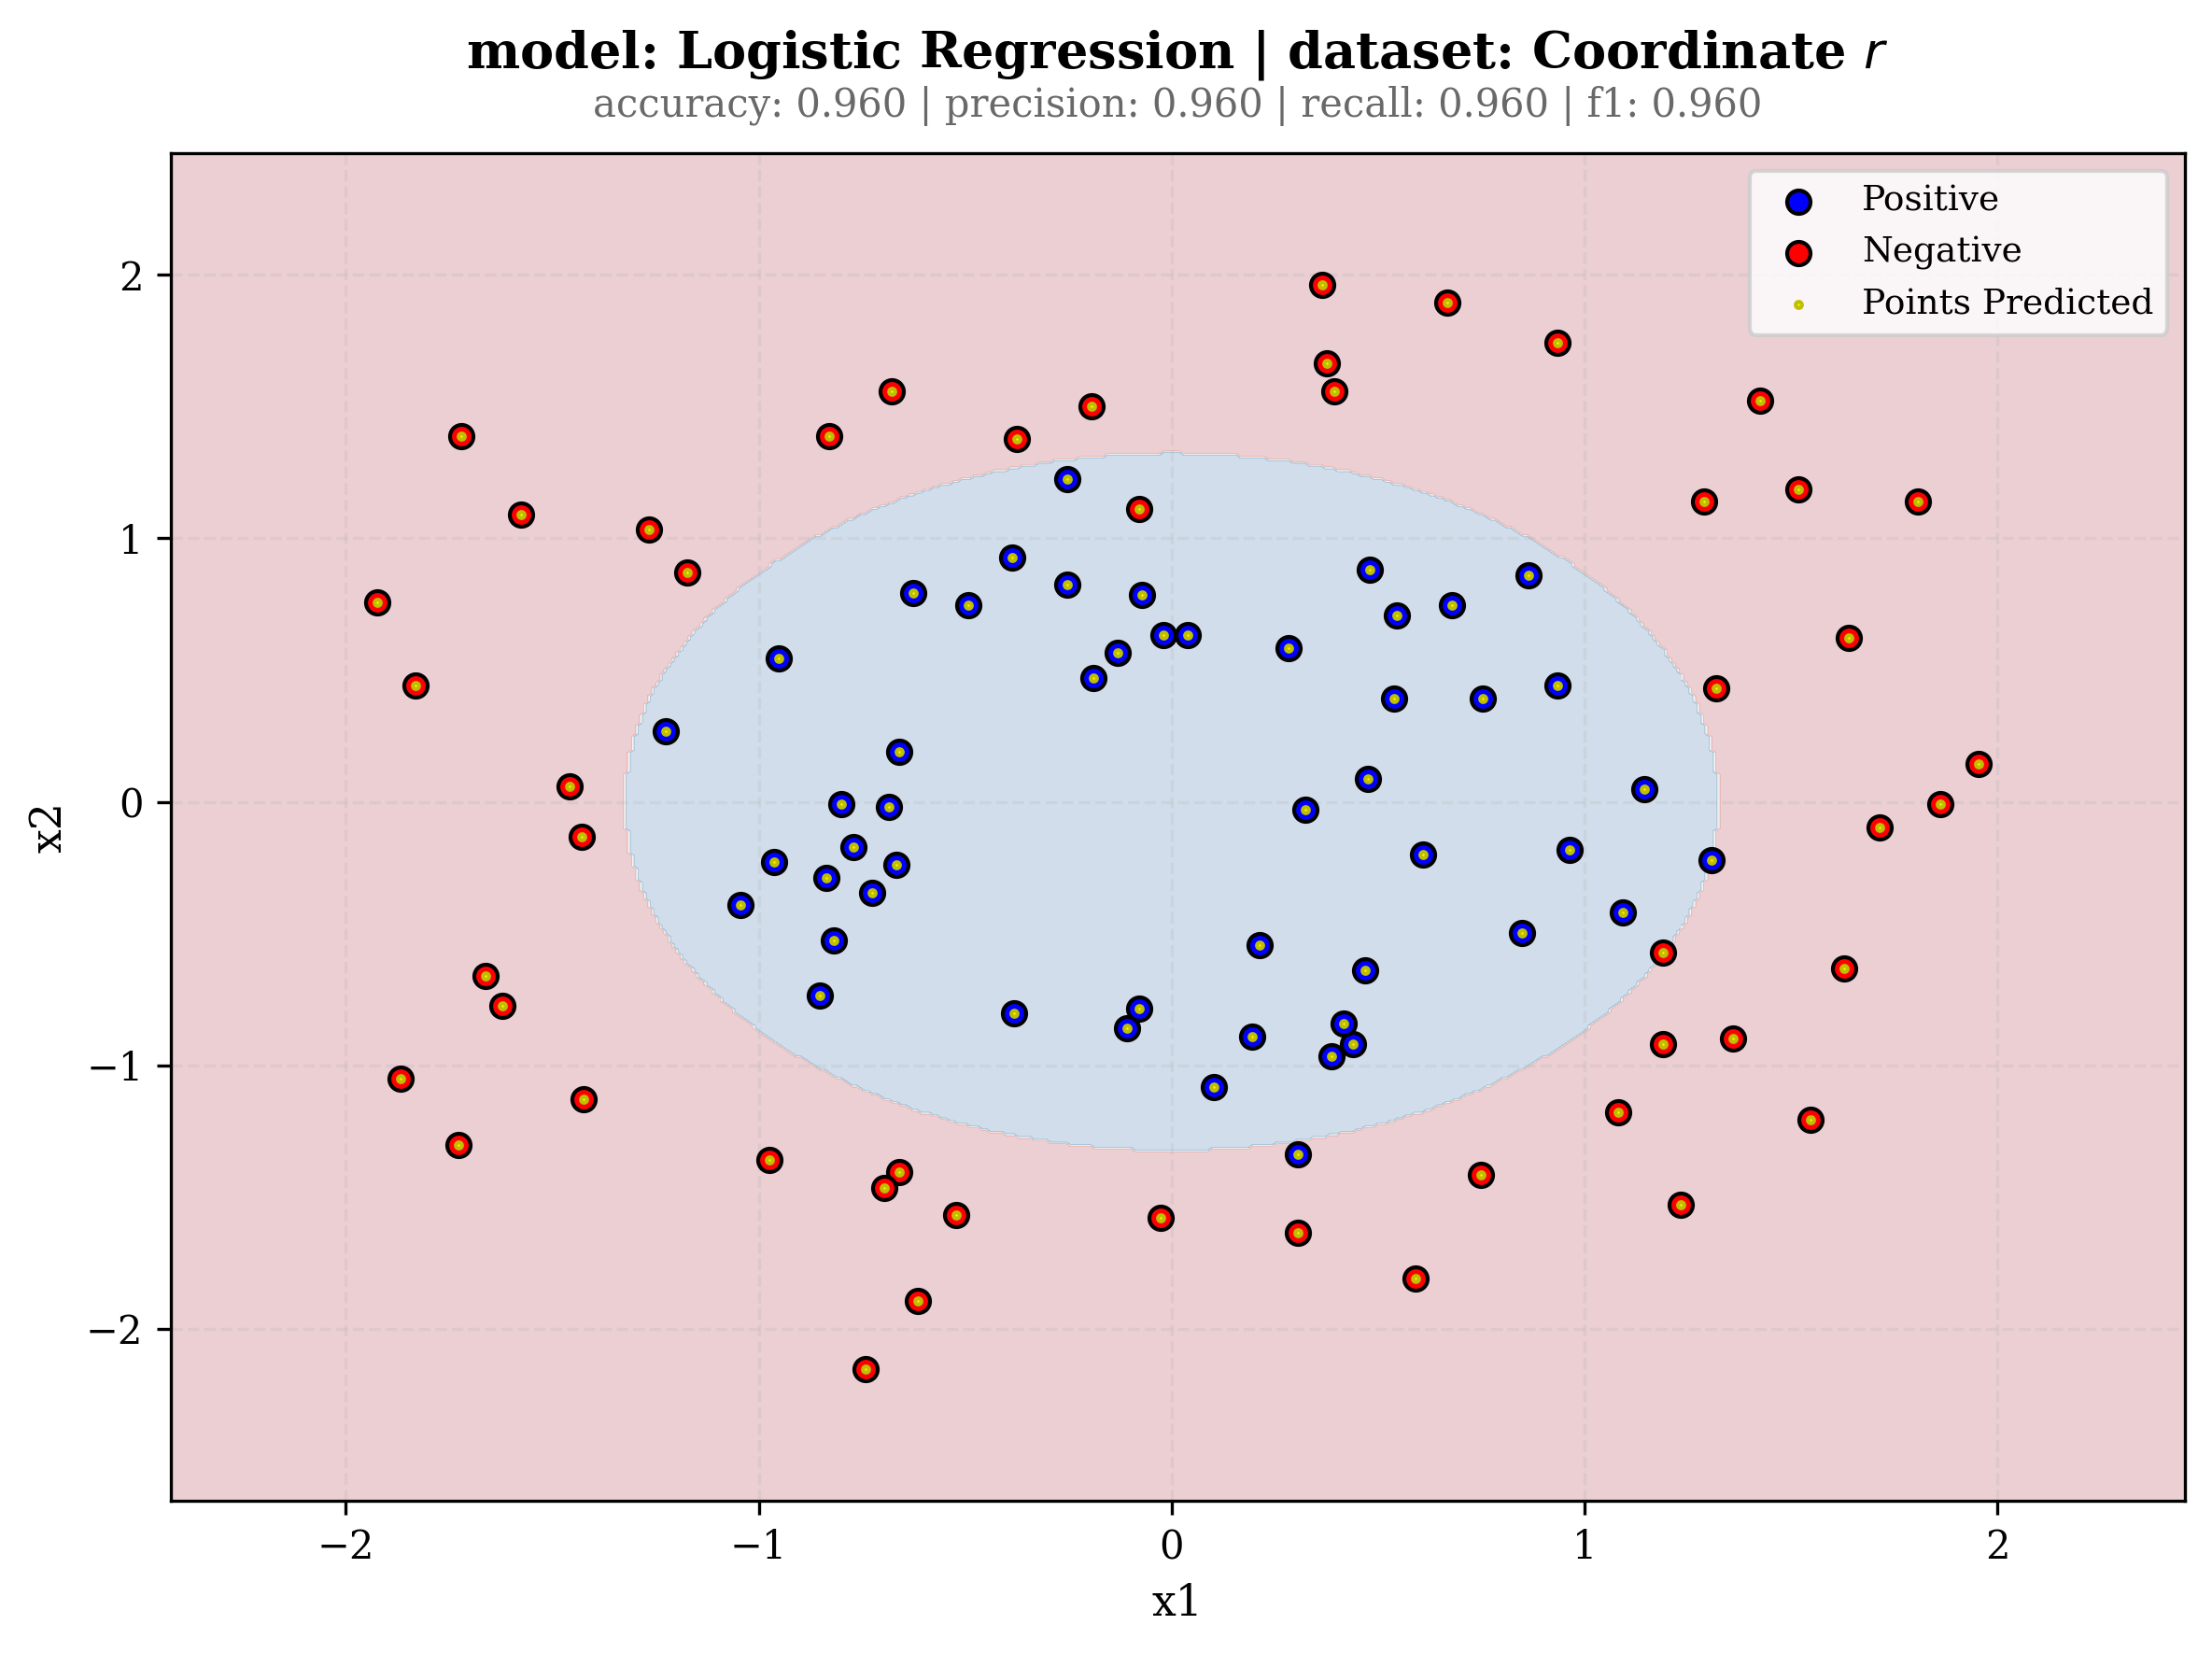

In [40]:
# Naive linear regression
vars_list = ['x1']
only_x = polar_dataset.X[vars_list]
model = train_logistic_regression(only_x, polar_dataset.y)

lr_metrics = ModelMetrics('Logistic Regression', 'Polar', polar_dataset.y, model.predict(only_x))
lr_metrics.compute_metrics()

wrapped_model = Model1DWrapper(trained_model=model, vars_list=vars_list)

fig, ax = plot_decision_boundary(
    model=wrapped_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {lr_metrics.metadata['model']} | dataset: Coordinate $r$',
    metrics=lr_metrics.to_dict(),
)

display(fig)

Decision boundary and metrics are very similar to those of the complete polar dataset

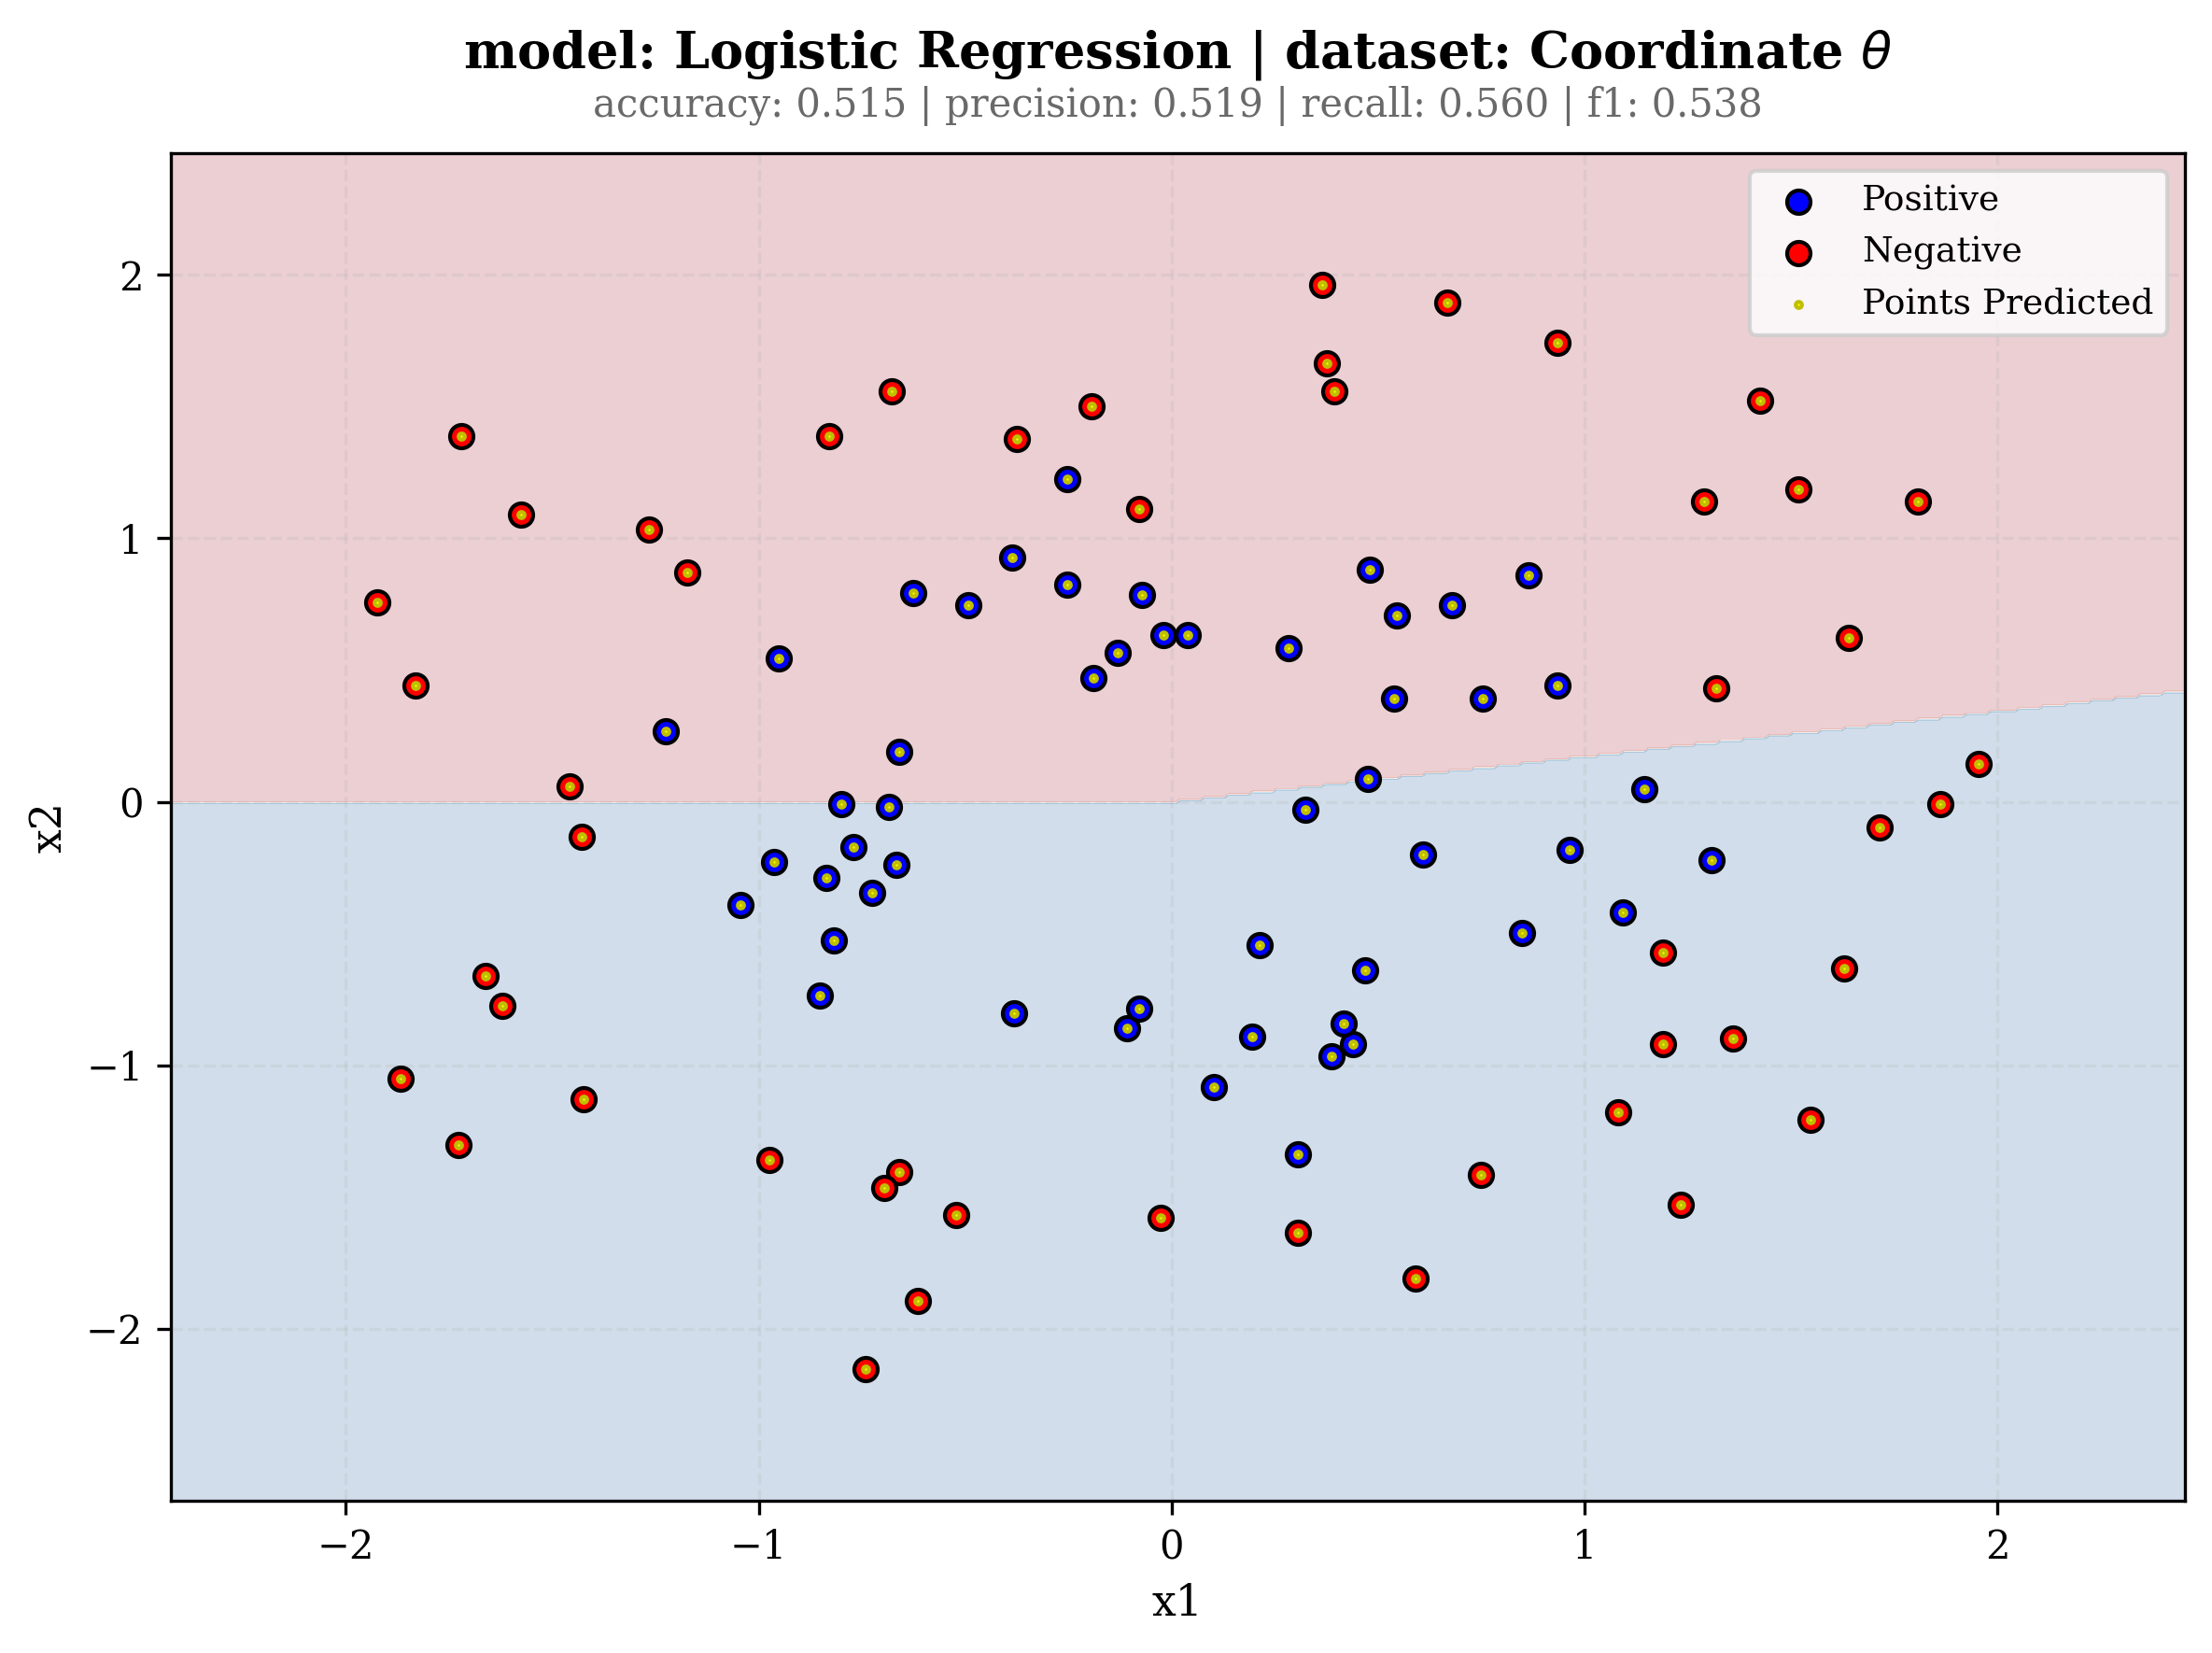

In [41]:
# Naive linear regression
vars_list = ['x2']
only_x = polar_dataset.X[vars_list]
model = train_logistic_regression(only_x, polar_dataset.y)

lr_metrics = ModelMetrics('Logistic Regression', 'Polar', polar_dataset.y, model.predict(only_x))
lr_metrics.compute_metrics()

wrapped_model = Model1DWrapper(trained_model=model, vars_list=vars_list)

fig, ax = plot_decision_boundary(
    model=wrapped_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_polar, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {lr_metrics.metadata['model']} | dataset: Coordinate $\theta$',
    metrics=lr_metrics.to_dict(),
)

display(fig)

Anguar coordinate alone does not produce a useful decision boundary

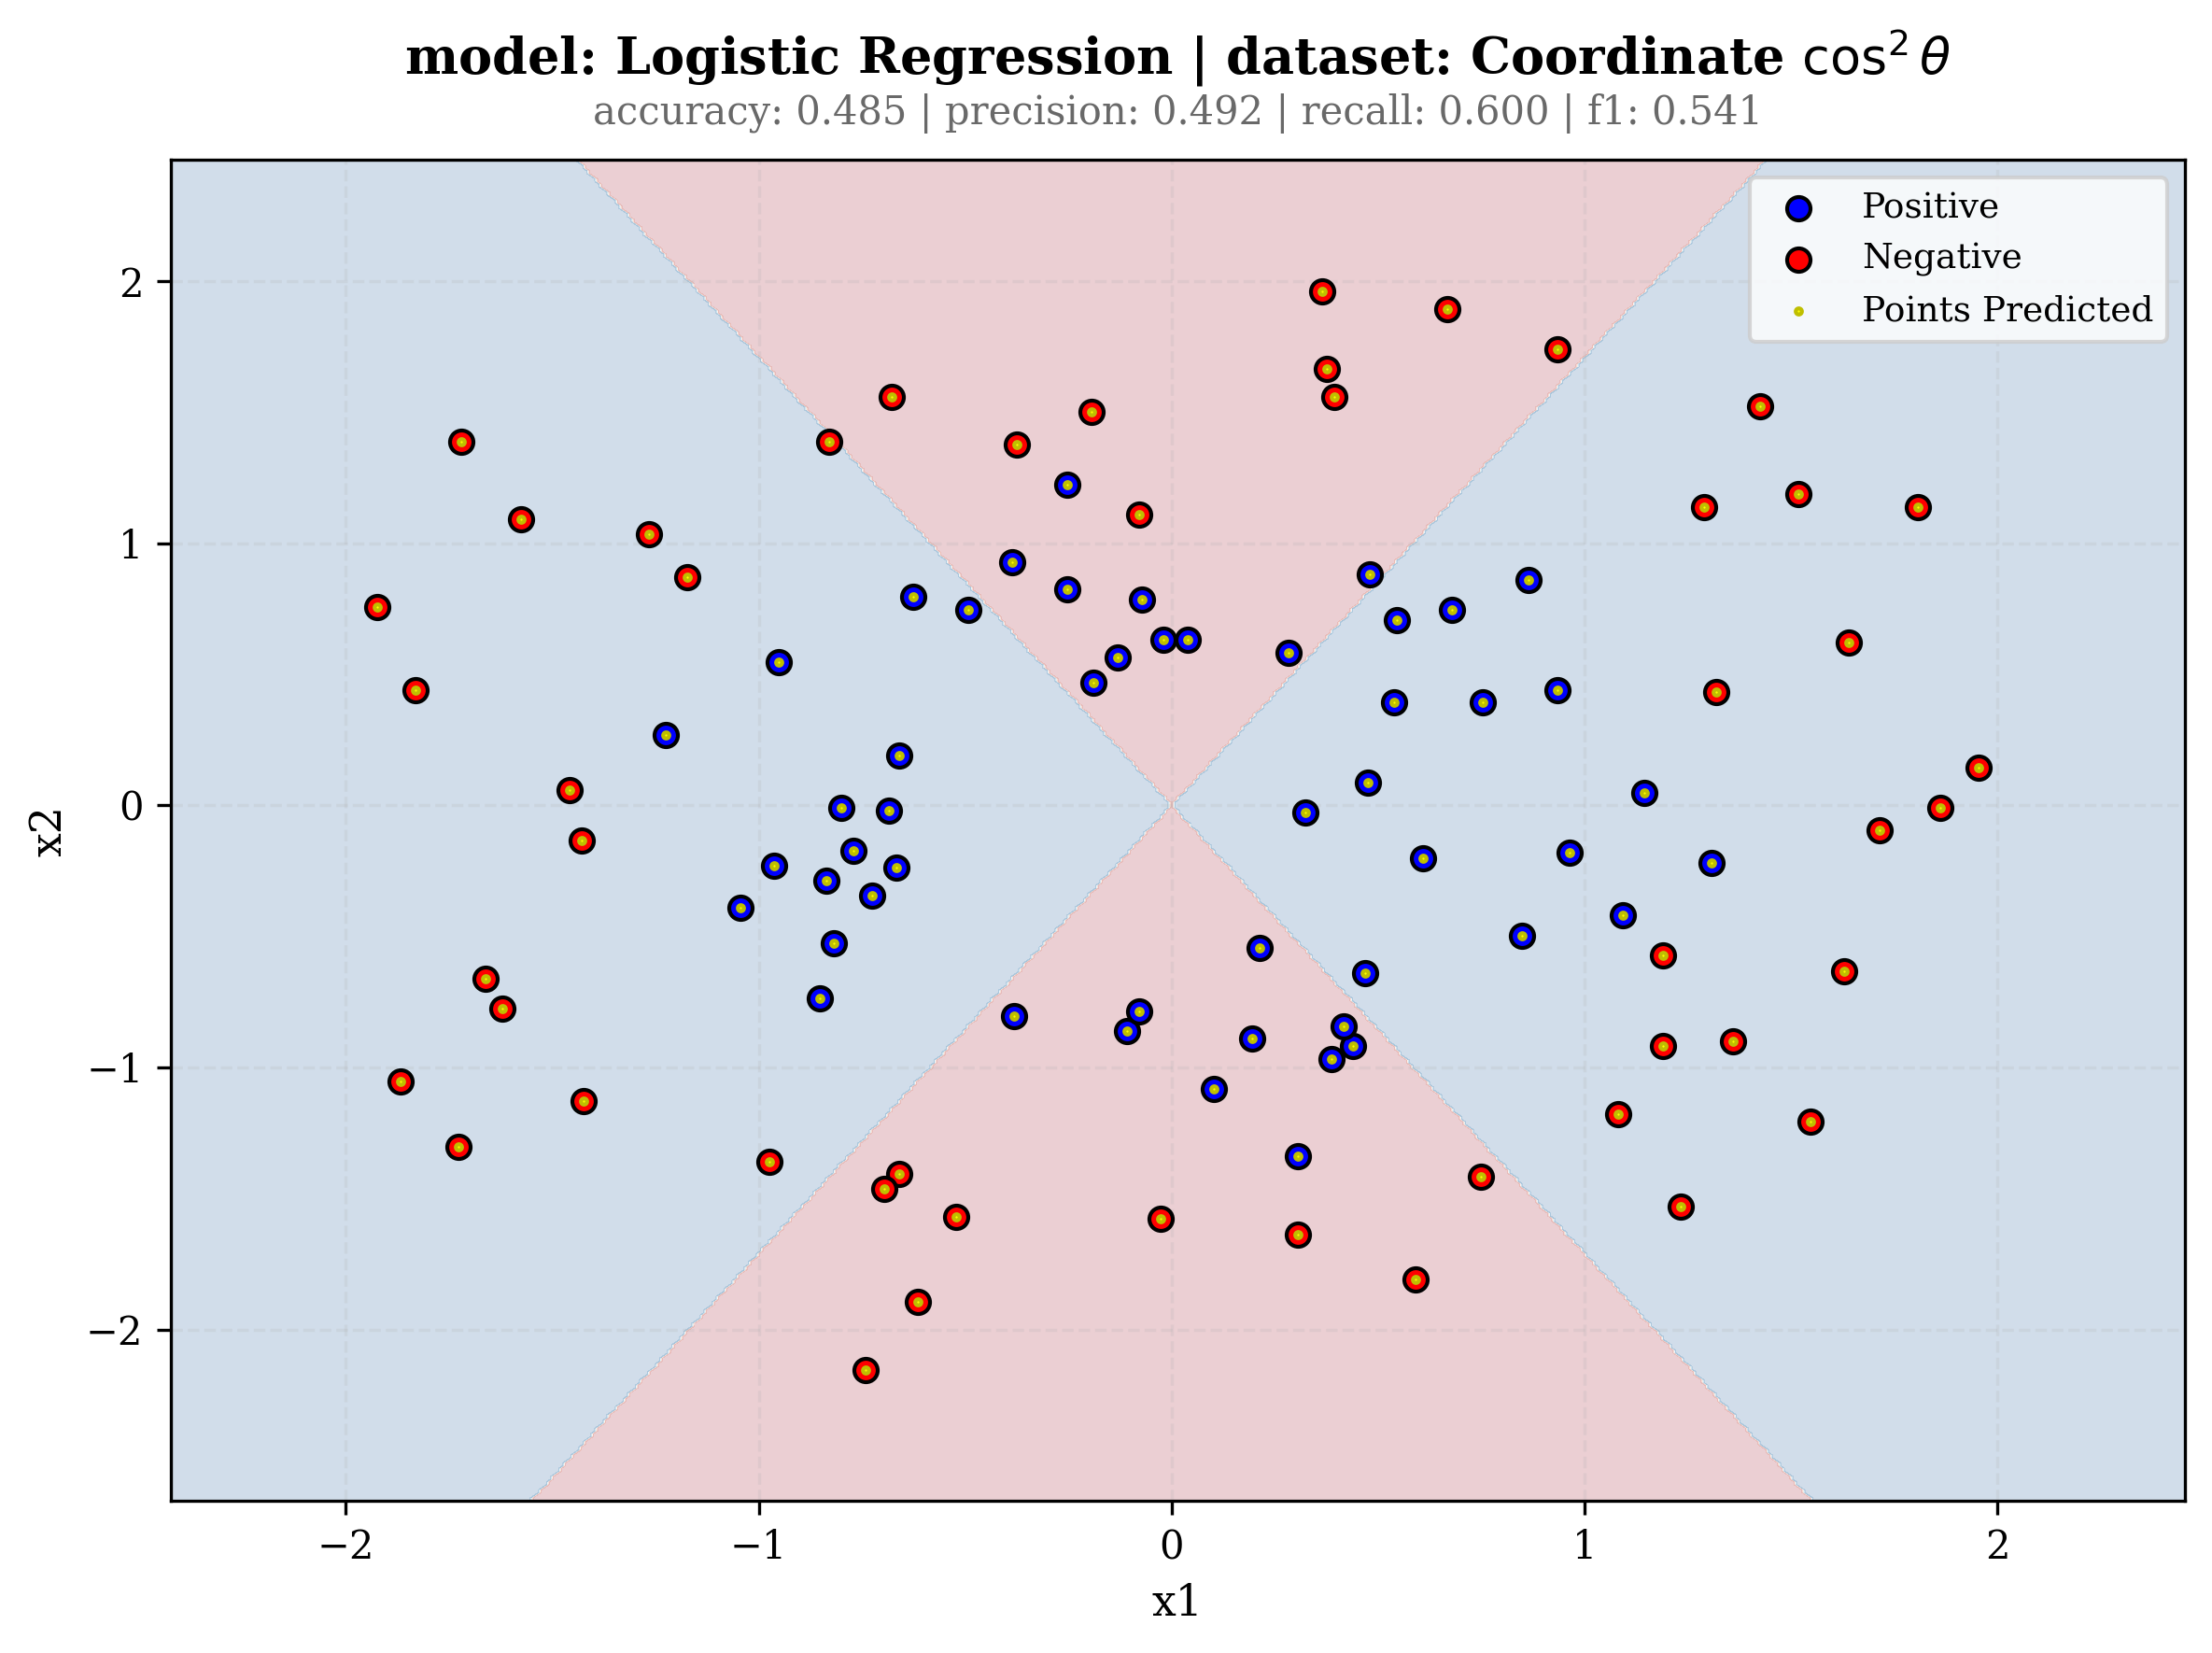

In [42]:
# Naive linear regression
vars_list = ['x2']
only_x = cos_sqd_dataset.X[vars_list]
model = train_logistic_regression(only_x, cos_sqd_dataset.y)

lr_metrics = ModelMetrics('Logistic Regression', 'Polar', cos_sqd_dataset.y, model.predict(only_x))
lr_metrics.compute_metrics()

wrapped_model = Model1DWrapper(trained_model=model, vars_list=vars_list)

dataset_name = r'$\cos^2{\theta}$'

fig, ax = plot_decision_boundary(
    model=wrapped_model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_cos_sqd, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {lr_metrics.metadata['model']} | dataset: Coordinate {dataset_name}',
    metrics=lr_metrics.to_dict(),
)

display(fig)

Decision boundary is not good, but it reflects more of the data's symmetry

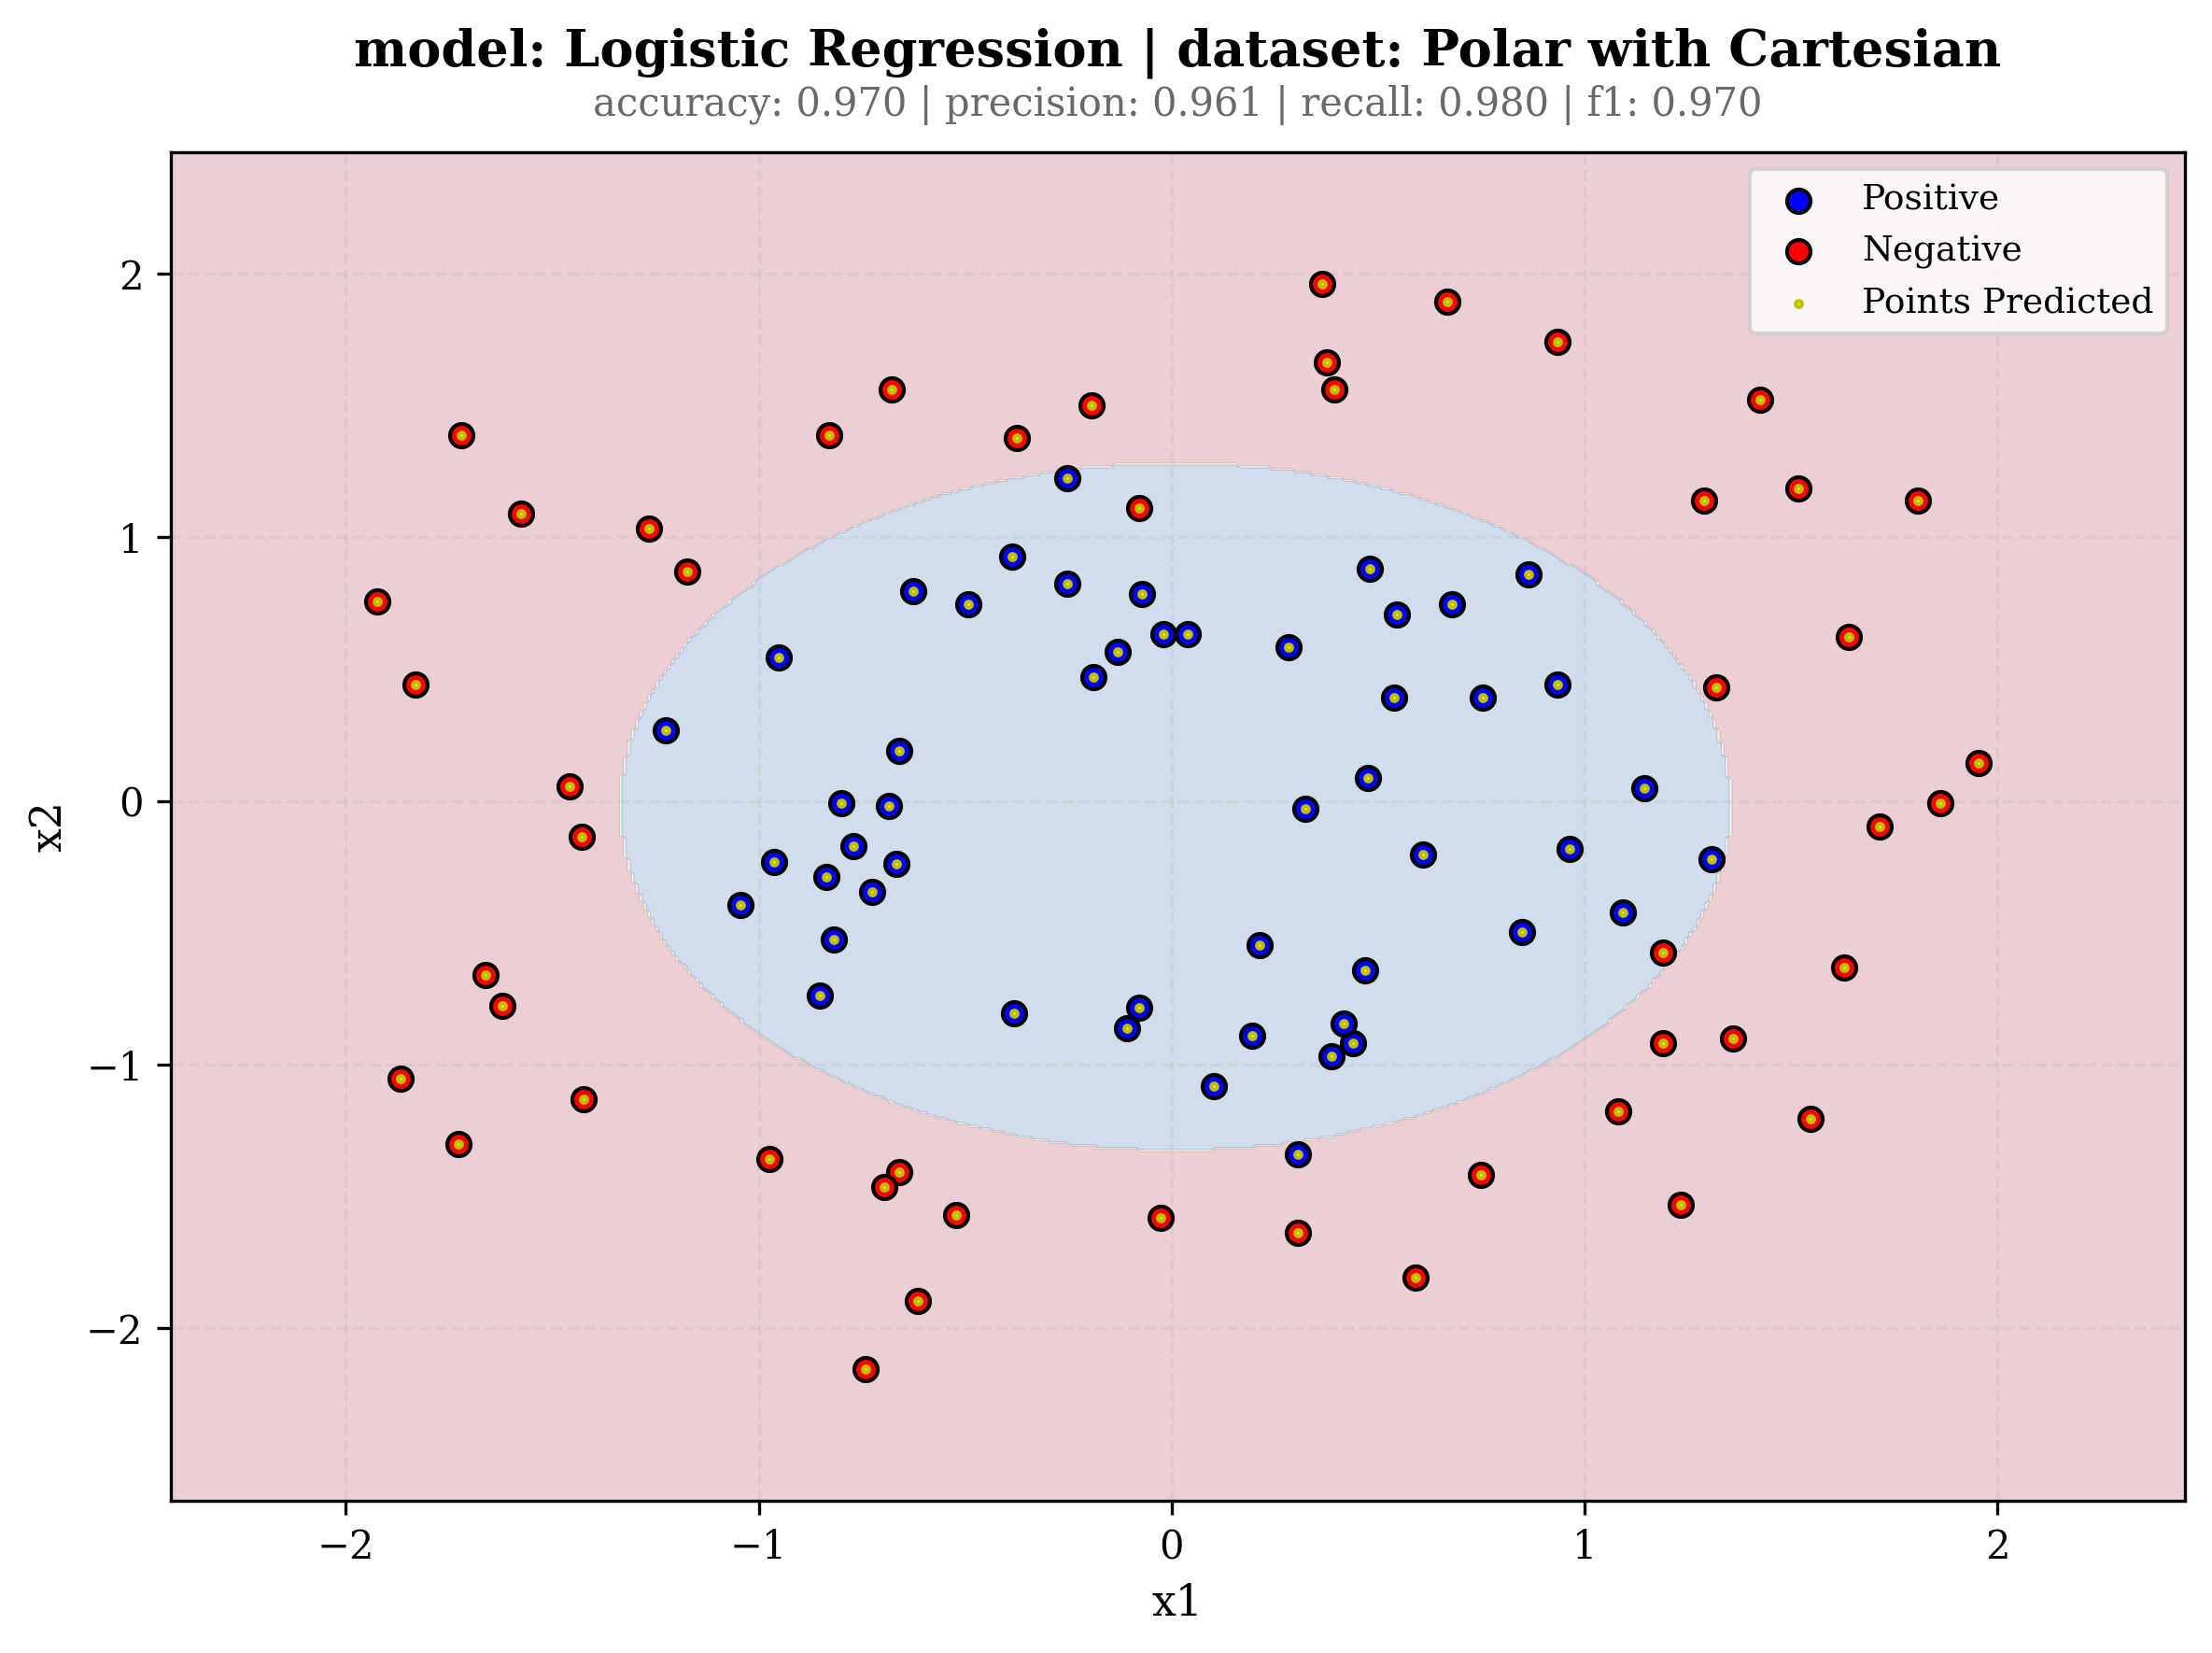

In [43]:
# extended dataset
extended_dataset = pd.concat([dataset.X, cos_sqd_dataset.X.rename(columns={'x1': 'r', 'x2': 'cos2_theta'})], axis=1)
grid_extended = pd.concat([grid_cartesian, grid_cos_sqd.rename(columns={'x1': 'r', 'x2': 'cos2_theta'})], axis=1)

model = train_logistic_regression(extended_dataset, dataset.y)

lr_metrics = ModelMetrics('Logistic Regression', 'Polar', cos_sqd_dataset.y, model.predict(extended_dataset))
lr_metrics.compute_metrics()

dataset_name = r'$\cos^2{\theta}$'

fig, ax = plot_decision_boundary(
    model=model, dataset_X=dataset.X, dataset_y=dataset.y,
    prediction_domain=grid_extended, grid_x=grid_x, grid_y=grid_y,
    title=fr'model: {lr_metrics.metadata['model']} | dataset: Polar with Cartesian',
    metrics=lr_metrics.to_dict(),
)

display(fig)

Including the Cartesian coordinates along with the polar dataset does not improve the performance obtained by the polar dataset alone

## Permutation Test